In [1]:
% setup environment
% clear data and number format
clear; format short e
% set path to equilibrium solver
txt=pwd; n=length(txt); rootpath=txt;
n=strfind(rootpath,"USERS"); rootpath=txt(1:n-2);
PHREEQCpath=[rootpath,'/runPHREEQC']
addpath(PHREEQCpath);
JEQUILIBpath=[rootpath,'/JEQUILIB'];
addpath(JEQUILIBpath);
% turn off warnings
warning off
%graphics_toolkit ("notebook"); 
%graphics_toolkit ("plotly"); 
graphics_toolkit("gnuplot")
% delete phreeqcrunfile
%system("rm porttest.txt");
%system('export PATH="$PATH:PHREEQCpath"')
%system('phreeqc')


PHREEQCpath = /home/jupyter/DrSmith/GeochemEquilib/runPHREEQC


In [2]:
database=['llnl.dat'];

In [3]:
% variables

% amounts
XP=0.020; XPstr=num2str(XP);
XC=1e-6; XCstr=num2str(XC);
XW=0.0011; XWstr=num2str(XW);
logPCO2=-3.3;   % PCO2. measured at 468.4 ppm average in the room 
logPCO2str=num2str(logPCO2);

% Ksp values
KspP=0.00000660693; KspPstr=num2str(KspP); % from https://www.aqion.de/site/16 0.00000660693
KspC=10^-8.48; KspCstr=num2str(KspC); % for calcite from aquaion 
KspW=10^3.4; KspWstr=num2str(KspW); %google AI reported the value. combine with SiO3+H=HSiO3 Ka value

% rate constants

kP=9e-1; kPstr=num2str(kP); %port dissoltuion
kC=0.04e-2;  kCstr=num2str(kC); %calciate ppte
kCO2=0.63e-3; kCO2str=num2str(kCO2); % gas transfer
kW=3e-1; kWstr=num2str(kW); %wollastonite solubility rate

% time vector
logtime=0.05:0.05:2.2; time=[10.^logtime];
%timetry=[0.00 0.10 2.00 24.00 48.00 72.00 96.00 144.00]; time=timetry;

In [4]:
solutionboxtext=[...
{'SOLUTION 1\n'}
{'       pe      13.75\n'}
{'       pH      5.65\n'}
{'       temp    25\n'}
{'-units mol/kgw\n'}
   ];
[nolinesSOLN,length]=size(solutionboxtext);

In [5]:
rateboxtext=[...
{'RATES\n'}

{'Portlandite\n'}
{'-start\n'}
{'1   REM   PARM(1) = rate constant. PARM(2) Ksp for portlandite \n'}
{'2 Ca=Act("Ca+2")\n'}
{'3 OH=Act("OH-")\n'}
{'4 IAP=Ca*OH^2\n'}
{'5 Ksp=PARM(2)\n'}
{'6 si_pp=log(IAP/Ksp)\n'}
{'20  IF (M <= 0  and si_pp < 0) THEN GOTO 200\n'}
{'120 rate = PARM(1) *M* (1 - (10^(si_pp))^0.48)\n'}
{'140 moles = rate*TIME\n'}
{'200 SAVE moles\n'}
{'   -end\n'}

{'Calcite\n'}
{'-start\n'}
{'-start\n'}
{'1   REM   PARM(1) = rate constant. Parm(2)=Ksp calcite\n'}
{'2 Ca=Act("Ca+2")\n'}
{'3 CO3=Act("CO3-2")\n'}
{'4 IAP=Ca*CO3\n'}
{'5 Ksp=PARM(2)\n'}
{'6 si_cc=log(IAP/Ksp)\n'}
{'20  IF (M <= 0  and si_cc < 0) THEN GOTO 200\n'}
{'120 rate = PARM(1) *M* (1 - (10^(si_cc))^0.48)\n'}
{'140 moles = rate*TIME\n'}
{'200 SAVE moles\n'}
{'   -end\n'}

{'Wollastonite\n'}
{'-start\n'}
{'1   REM   PARM(1) = rate constant. Parm(2)=Ksp Wollastonite\n'}
{'2 Ca=Act("Ca+2")\n'}
{'3 HSiO3=Act("HSiO3-")\n'}
{'4 H=Act("H+")\n'}
{'5 IAP=(Ca*HSiO3)/H \n'}
{'6 Ksp=PARM(2)\n'}
{'7 si_ww=log(IAP/Ksp)\n'}
{'20  IF (M <= 0  and si_cc < 0) THEN GOTO 200\n'}
{'120 rate = PARM(1) *M* (1 - (10^(si_ww)))\n'}
{'140 moles = rate*TIME\n'}
{'200 SAVE moles\n'}
{'   -end\n'}

{'CO2_dissolution\n'}
{'-start\n'}
{'20 k = parm(2)\n'}
{'30 eq_HCO3 = 10^PARM(1)*10^LK_PHASE("CO2(g)")/ACT("H+")\n'}
{'40 act_HCO3 = ACT("HCO3-")\n'}
{'50 moles = k * (1-(act_HCO3/eq_HCO3)^0.2) * TIME\n'}
{'60 SAVE moles\n'}
{'   -end\n'}
];
[nolinesRATE,length]=size(rateboxtext);

In [6]:
m0Pline=['  -m0    ',XPstr,'\n'];
mPline=['  -m    ',XPstr,'\n'];
parmsPline=['  -parms ',kPstr,' ',KspPstr,'\n'];

m0Cline=['  -m0    ',XCstr,'\n'];
mCline=['  -m    ',XCstr,'\n'];
parmsCline=['  -parms ',kCstr,' ',KspCstr,'\n'];

m0Wline=['  -m0    ',XWstr,'\n'];
mWline=['  -m    ',XWstr,'\n'];
parmsWline=['  -parms ',kWstr,' ',KspWstr,'\n'];

parmsCO2line=['  -parms ',logPCO2str,' ',kCO2str,'\n'];
timestr=mat2str([0 time]); timestr = regexprep(timestr,'\[','');  timestr = regexprep(timestr,'\]','');
timeline=[' -steps ',timestr,' s\n'];

kineticsboxtext=[...
{'KINETICS 1\n'}

{'Portlandite\n'}
{'  -tol   1e-13\n'}
{m0Pline}
{mPline}
{parmsPline}

{'Calcite\n'}
{'  -tol   1e-13\n'}
{m0Cline}
{mCline}
{parmsCline}

{'Wollastonite\n'}
{'  -tol   1e-13\n'}
{m0Wline}
{mWline}
{parmsWline}

{'CO2_dissolution\n'}
{'  -tol   1e-13\n'}
{'-formula CO2 1\n'}
{parmsCO2line}
{timeline}

{'  -cvode\n'}
{'-runge_kutta      6\n'}
];

[nolinesKIN,length]=size(kineticsboxtext);

In [7]:
selectboxtext=[...
{' SELECTED_OUTPUT\n'}
{' -file portout.txt\n'}
{' -selected_out true\n'}
{' -user_punch true\n'}
{' -high_precision true\n'}
{' -reset false\n'}
{' -simulation false\n'}
{' -state false\n'}
{' -distance false\n'}
{' -time false\n'}
{' -step false\n'}
{' -ph false\n'}
{' -pe false\n'}
{' -reaction false\n'}
{' -temperature false\n'}
{' -alkalinity false\n'}
{' -ionic_strength false\n'}
{' -water false\n'}
{' -charge_balance false\n'}
{' -percent_error false\n'}
];
[nolinesSEL,length]=size(selectboxtext);

In [8]:
punchboxtext=[...
{'USER_PUNCH\n'}
{'        -headings seconds  Ca  pH Calcite  Portlandite DIC Si\n'}
{'  10 PUNCH SIM_TIME, TOT("Ca"), -LA("H+"), KIN("Calcite"), KIN("Portlandite"), TOT("C"), TOT("Si") \n'}
];
[nolinesPUNCH,length]=size(punchboxtext);

In [9]:
fileID=fopen('porttest.txt','w');

fprintf(fileID,'TITLE TEST PORTLANDITE DISSOLUTION\n');

for i=1:nolinesSOLN
    line=cell2mat(solutionboxtext(i,:));
    fprintf(fileID,line)
end
fprintf(fileID,'\n');
for i=1:nolinesRATE
    line=cell2mat(rateboxtext(i,:));
    fprintf(fileID,line)
end
fprintf(fileID,'\n');
for i=1:nolinesKIN
    line=cell2mat(kineticsboxtext(i,:));
    fprintf(fileID,line)
end
fprintf(fileID,'\n');
for i=1:nolinesSEL
    line=cell2mat(selectboxtext(i,:));
    fprintf(fileID,line)
end
fprintf(fileID,'\n');
for i=1:nolinesPUNCH
    line=cell2mat(punchboxtext(i,:));
    fprintf(fileID,line)
end
fprintf(fileID,'\n');
fprintf(fileID,'END');
fclose(fileID);

In [10]:
str=['system("/home/jupyter/DrSmith/GeochemEquilib/runPHREEQC/phreeqc porttest.txt out.txt ', database,'");'];
eval(str); % output to the screen
%evalc(str); % so no screen output
fid = fopen('portout.txt','rt');
hdr = strtrim(regexp(fgetl(fid),'\t','split'));
hdr=hdr(1:7)';
mat = cell2mat(textscan(fid,repmat('%f',1,numel(hdr))));
[nsize,msize]=size(mat);
time=mat(2:nsize,1); Caphreeqc=mat(2:nsize,2); pHphreeqc=mat(2:nsize,3);
calcitephreeqc=mat(2:nsize,4); portlanditephreeqc=mat(2:nsize,5);
DIC=mat(2:nsize,6); Siaq=mat(2:nsize,7);

Input file: porttest.txt

Output file: out.txt

Database file: llnl.dat


Initializing...                                                                 







Simulation 1. Kinetic step 2.                                                  











Simulation 1. Kinetic step 3.                                                  









Simulation 1. Kinetic step 4.                                                  









Simulation 1. Kinetic step 5.                                                  









Simulation 1. Kinetic step 6.                                                  









Simulation 1. Kinetic step 7.                                                  









Simulation 1. Kinetic step 8.                                                  









Simulation 1. Kinetic step 8.                                                  











Simulation 1. Kinetic step 9.                                                  









Simulation 1. Kinetic step 10.   

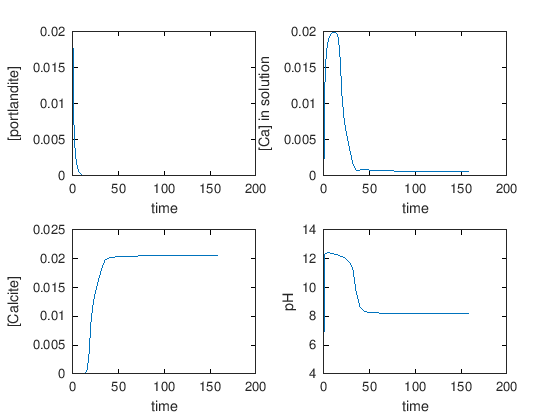

In [11]:

subplot(221); plot(time,portlanditephreeqc); ylabel('[portlandite]'); xlabel('time')
subplot(222); plot(time,Caphreeqc); ylabel('[Ca] in solution'); xlabel('time')
subplot(223); plot(time,calcitephreeqc); ylabel('[Calcite]'); xlabel('time')
subplot(224); plot(time,pHphreeqc); ylabel('pH'); xlabel('time')



In [12]:
% data
%6 g cement small size

data=[...
%Sampling times (H)	pH	DIC (mmol/L)	Conductivity (us/cm)	Ca2+ (mmol/L)	Si (mmol/L)
0.00	4.16	-0.04	NaN	0.30275	-0.002
0.10	9.69	0.46	125.9	0.439575	0.052
2.00	8.59	0.60	102.6	0.482425	0.178
24.00	8.21	1.39	194.2	0.866125	0.277
48.00	8.17	1.36	212.9	0.844	0.307
72.00	8.23	1.42	222.2	0.818	0.317


];

sampletime=data(:,1); samplepH=data(:,2); sampleDIC=(data(:,3)*1e-3); conduct=data(:,4); sampleCa=(data(:,5)*1e-3); 
sampleSi=(data(:,6)*1e-3);


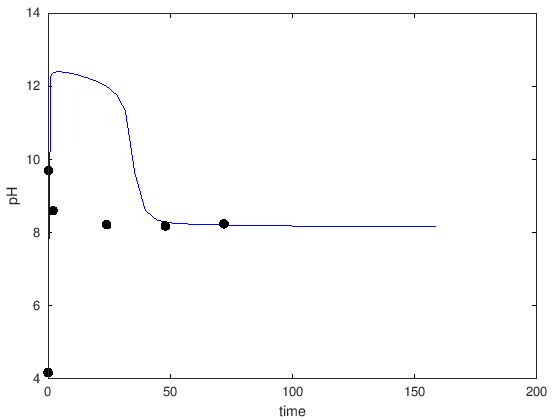

In [13]:
plot(time,pHphreeqc,'b-','linewidth',2); ylabel('pH'); xlabel('time')
hold on
%plot(timeres,pHres,'bo')
plot(sampletime,samplepH,'ko','markersize',8,'markerfacecolor','k')
set(gca,'linewidth',2)

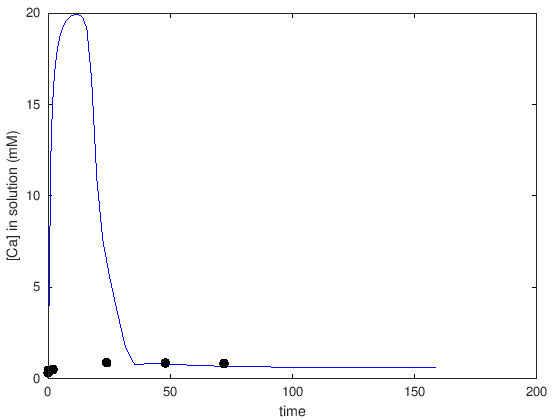

In [14]:
plot(time,(Caphreeqc*1e3),'b-','linewidth',2); ylabel('[Ca] in solution (mM)'); xlabel('time')
hold on
plot(sampletime,(sampleCa*1e3),'ko','markersize',8,'markerfacecolor','k')
set(gca,'linewidth',2)

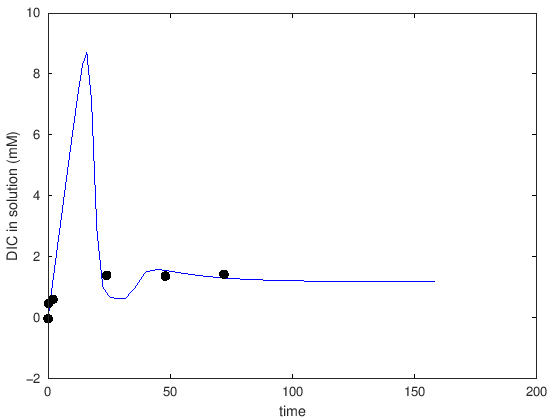

In [15]:
plot(time,1e3*DIC,'b-','linewidth',2); ylabel('DIC in solution (mM)'); xlabel('time')
hold on
plot(sampletime,sampleDIC*1e3,'ko','markersize',8,'markerfacecolor','k')
set(gca,'linewidth',2)

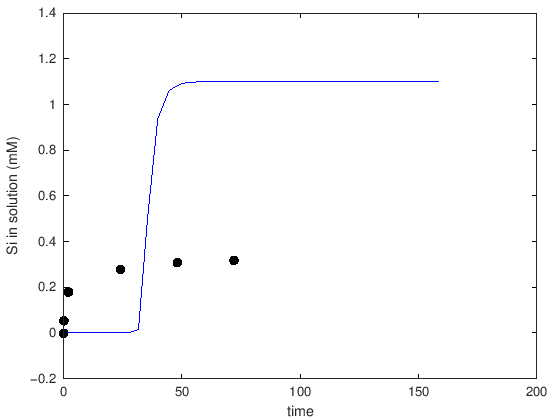

In [16]:
plot(time,1e3*(Siaq),'b-','linewidth',2); ylabel('Si in solution (mM)'); xlabel('time')
hold on
plot(sampletime,sampleSi*1e3,'ko','markersize',8,'markerfacecolor','k')
set(gca,'linewidth',2)

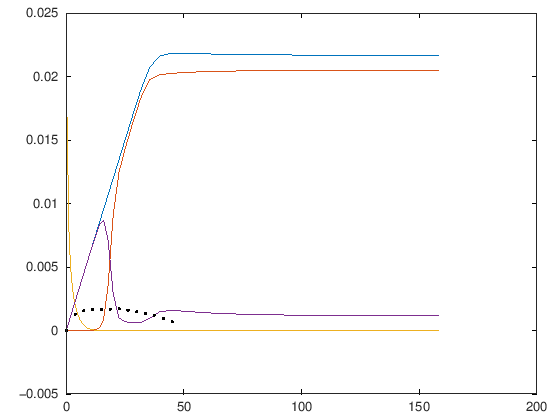

In [17]:
% plot total C that ends up in solution

CTsoln=DIC+calcitephreeqc;

%plot(time,CTsoln,time,calcite,time,port,time,DIC,sampletime,sampleDIC,'r.')
plot(time,CTsoln,time,calcitephreeqc,time,portlanditephreeqc,time,DIC,'linewidth',2)


data=[...
%Time (min)	Time(h)	Carbon dioxide(ppm)		CO2_input (mol)	CO2_out (mol)	△ CO2 consumed (mol)	CO2 capture rate （umol/5 min）	CO2 capture rate （umol/h）	CO2 capture （umol）
0	0.00	448.08	5.4254E-05	6.5296E-05	-1.1042E-05	-1.1042E+01	-1.3251E+02	-1.1042E+01
4.9998	0.08	540.38	5.4254E-05	3.8109E-05	1.6145E-05	1.6145E+01	1.9374E+02	5.1029E+00
10.0002	0.17	315.38	5.4254E-05	2.2889E-05	3.1366E-05	3.1366E+01	3.7639E+02	3.6468E+01
15	0.25	189.42	5.4254E-05	1.4291E-05	3.9963E-05	3.9963E+01	4.7956E+02	7.6432E+01
19.9998	0.33	118.27	5.4254E-05	1.3245E-05	4.1009E-05	4.1009E+01	4.9211E+02	1.1744E+02
25.0002	0.42	109.62	5.4254E-05	1.2548E-05	4.1706E-05	4.1706E+01	5.0047E+02	1.5915E+02
30	0.50	103.85	5.4254E-05	1.0921E-05	4.3333E-05	4.3333E+01	5.1999E+02	2.0248E+02
34.9998	0.58	90.38	5.4254E-05	1.2316E-05	4.1938E-05	4.1938E+01	5.0326E+02	2.4442E+02
40.0002	0.67	101.92	5.4254E-05	1.1967E-05	4.2287E-05	4.2287E+01	5.0744E+02	2.8670E+02
45	0.75	99.04	5.4254E-05	1.2432E-05	4.1822E-05	4.1822E+01	5.0187E+02	3.2853E+02
49.9998	0.83	102.88	5.4254E-05	1.0805E-05	4.3449E-05	4.3449E+01	5.2139E+02	3.7198E+02
55.0002	0.92	89.42	5.4254E-05	1.2083E-05	4.2171E-05	4.2171E+01	5.0605E+02	4.1415E+02
60	1.00	100.00	5.4254E-05	1.2780E-05	4.1474E-05	4.1474E+01	4.9768E+02	4.5562E+02
64.9998	1.08	105.77	5.4254E-05	1.3245E-05	4.1009E-05	4.1009E+01	4.9211E+02	4.9663E+02
70.0002	1.17	109.62	5.4254E-05	1.1967E-05	4.2287E-05	4.2287E+01	5.0744E+02	5.3892E+02
75	1.25	99.04	5.4254E-05	1.2432E-05	4.1822E-05	4.1822E+01	5.0187E+02	5.8074E+02
79.9998	1.33	102.88	5.4254E-05	1.3826E-05	4.0428E-05	4.0428E+01	4.8514E+02	6.2117E+02
85.0002	1.42	114.42	5.4254E-05	1.3826E-05	4.0428E-05	4.0428E+01	4.8514E+02	6.6160E+02
90	1.50	114.42	5.4254E-05	1.3942E-05	4.0312E-05	4.0312E+01	4.8374E+02	7.0191E+02
94.9998	1.58	115.38	5.4254E-05	1.4872E-05	3.9382E-05	3.9382E+01	4.7259E+02	7.4129E+02
100.0002	1.67	123.08	5.4254E-05	1.3826E-05	4.0428E-05	4.0428E+01	4.8514E+02	7.8172E+02
105	1.75	114.42	5.4254E-05	1.7893E-05	3.6362E-05	3.6362E+01	4.3634E+02	8.1808E+02
109.9998	1.83	148.08	5.4254E-05	1.5917E-05	3.8337E-05	3.8337E+01	4.6004E+02	8.5642E+02
115.0002	1.92	131.73	5.4254E-05	1.9752E-05	3.4503E-05	3.4503E+01	4.1403E+02	8.9092E+02
120	2.00	163.46	5.4254E-05	2.1262E-05	3.2992E-05	3.2992E+01	3.9591E+02	9.2391E+02
124.9998	2.08	175.96	5.4254E-05	2.1611E-05	3.2644E-05	3.2644E+01	3.9172E+02	9.5655E+02
130.0002	2.17	178.85	5.4254E-05	2.4283E-05	2.9971E-05	2.9971E+01	3.5966E+02	9.8653E+02
135	2.25	200.96	5.4254E-05	2.7536E-05	2.6718E-05	2.6718E+01	3.2062E+02	1.0132E+03
139.9998	2.33	227.88	5.4254E-05	2.7652E-05	2.6602E-05	2.6602E+01	3.1922E+02	1.0398E+03
145.0002	2.42	228.85	5.4254E-05	3.2067E-05	2.2187E-05	2.2187E+01	2.6624E+02	1.0620E+03
150	2.50	265.38	5.4254E-05	3.2416E-05	2.1838E-05	2.1838E+01	2.6206E+02	1.0839E+03
154.9998	2.58	268.27	5.4254E-05	3.4623E-05	1.9631E-05	1.9631E+01	2.3557E+02	1.1035E+03
160.0002	2.67	286.54	5.4254E-05	3.6018E-05	1.8237E-05	1.8237E+01	2.1884E+02	1.1217E+03
165	2.75	298.08	5.4254E-05	3.6250E-05	1.8004E-05	1.8004E+01	2.1605E+02	1.1397E+03
169.9998	2.83	300.00	5.4254E-05	3.8690E-05	1.5564E-05	1.5564E+01	1.8677E+02	1.1553E+03
175.0002	2.92	320.19	5.4254E-05	3.8690E-05	1.5564E-05	1.5564E+01	1.8677E+02	1.1709E+03
180	3.00	320.19	5.4254E-05	4.0897E-05	1.3357E-05	1.3357E+01	1.6028E+02	1.1842E+03
184.9998	3.08	338.46	5.4254E-05	4.1711E-05	1.2543E-05	1.2543E+01	1.5052E+02	1.1968E+03
190.0002	3.17	345.19	5.4254E-05	4.2059E-05	1.2195E-05	1.2195E+01	1.4634E+02	1.2090E+03
195	3.25	348.08	5.4254E-05	4.2873E-05	1.1382E-05	1.1382E+01	1.3658E+02	1.2203E+03
199.9998	3.33	354.81	5.4254E-05	4.3105E-05	1.1149E-05	1.1149E+01	1.3379E+02	1.2315E+03
205.0002	3.42	356.73	5.4254E-05	4.1943E-05	1.2311E-05	1.2311E+01	1.4773E+02	1.2438E+03
210	3.50	347.12	5.4254E-05	4.3686E-05	1.0568E-05	1.0568E+01	1.2682E+02	1.2544E+03
214.9998	3.58	361.54	5.4254E-05	4.5080E-05	9.1740E-06	9.1740E+00	1.1009E+02	1.2635E+03
220.0002	3.67	373.08	5.4254E-05	4.6010E-05	8.2446E-06	8.2446E+00	9.8935E+01	1.2718E+03
225	3.75	380.77	5.4254E-05	4.5313E-05	8.9417E-06	8.9417E+00	1.0730E+02	1.2807E+03
229.9998	3.83	375.00	5.4254E-05	4.4615E-05	9.6388E-06	9.6388E+00	1.1567E+02	1.2904E+03
235.0002	3.92	369.23	5.4254E-05	4.4034E-05	1.0220E-05	1.0220E+01	1.2264E+02	1.3006E+03
240	4.00	364.42	5.4254E-05	4.6474E-05	7.7798E-06	7.7798E+00	9.3358E+01	1.3084E+03
244.9998	4.08	384.62	5.4254E-05	4.7404E-05	6.8503E-06	6.8503E+00	8.2204E+01	1.3152E+03
250.0002	4.17	392.31	5.4254E-05	4.6591E-05	7.6636E-06	7.6636E+00	9.1963E+01	1.3229E+03
255	4.25	385.58	5.4254E-05	4.6591E-05	7.6636E-06	7.6636E+00	9.1963E+01	1.3306E+03
259.9998	4.33	385.58	5.4254E-05	4.7869E-05	6.3856E-06	6.3856E+00	7.6627E+01	1.3369E+03
265.0002	4.42	396.15	5.4254E-05	4.6242E-05	8.0122E-06	8.0122E+00	9.6146E+01	1.3449E+03
270	4.50	382.69	5.4254E-05	4.5313E-05	8.9417E-06	8.9417E+00	1.0730E+02	1.3539E+03
274.9998	4.58	375.00	5.4254E-05	4.5777E-05	8.4769E-06	8.4769E+00	1.0172E+02	1.3624E+03
280.0002	4.67	378.85	5.4254E-05	4.7404E-05	6.8503E-06	6.8503E+00	8.2204E+01	1.3692E+03
285	4.75	392.31	5.4254E-05	4.7636E-05	6.6179E-06	6.6179E+00	7.9415E+01	1.3758E+03
289.9998	4.83	394.23	5.4254E-05	4.8101E-05	6.1532E-06	6.1532E+00	7.3838E+01	1.3820E+03
295.0002	4.92	398.08	5.4254E-05	4.9495E-05	4.7590E-06	4.7590E+00	5.7108E+01	1.3867E+03
300	5.00	409.62	5.4254E-05	4.8682E-05	5.5723E-06	5.5723E+00	6.6867E+01	1.3923E+03
304.9998	5.08	402.88	5.4254E-05	4.9495E-05	4.7590E-06	4.7590E+00	5.7108E+01	1.3971E+03
310.0002	5.17	409.62	5.4254E-05	4.8217E-05	6.0370E-06	6.0370E+00	7.2444E+01	1.4031E+03
315	5.25	399.04	5.4254E-05	4.8333E-05	5.9208E-06	5.9208E+00	7.1050E+01	1.4090E+03
319.9998	5.33	400.00	5.4254E-05	4.8682E-05	5.5723E-06	5.5723E+00	6.6867E+01	1.4146E+03
325.0002	5.42	402.88	5.4254E-05	4.9611E-05	4.6428E-06	4.6428E+00	5.5713E+01	1.4193E+03
330	5.50	410.58	5.4254E-05	4.7520E-05	6.7341E-06	6.7341E+00	8.0810E+01	1.4260E+03
334.9998	5.58	393.27	5.4254E-05	4.8682E-05	5.5723E-06	5.5723E+00	6.6867E+01	1.4316E+03
340.0002	5.67	402.88	5.4254E-05	4.9611E-05	4.6428E-06	4.6428E+00	5.5713E+01	1.4362E+03
345	5.75	410.58	5.4254E-05	4.6823E-05	7.4313E-06	7.4313E+00	8.9175E+01	1.4436E+03
349.9998	5.83	387.50	5.4254E-05	4.8566E-05	5.6885E-06	5.6885E+00	6.8262E+01	1.4493E+03
355.0002	5.92	401.92	5.4254E-05	4.9263E-05	4.9913E-06	4.9913E+00	5.9896E+01	1.4543E+03
360	6.00	407.69	5.4254E-05	4.9379E-05	4.8752E-06	4.8752E+00	5.8502E+01	1.4592E+03
364.9998	6.08	408.65	5.4254E-05	4.9960E-05	4.2942E-06	4.2942E+00	5.1531E+01	1.4635E+03
370.0002	6.17	413.46	5.4254E-05	4.8217E-05	6.0370E-06	6.0370E+00	7.2444E+01	1.4695E+03
375	6.25	399.04	5.4254E-05	4.7752E-05	6.5018E-06	6.5018E+00	7.8021E+01	1.4760E+03
379.9998	6.33	395.19	5.4254E-05	4.7985E-05	6.2694E-06	6.2694E+00	7.5233E+01	1.4823E+03
385.0002	6.42	397.12	5.4254E-05	4.9147E-05	5.1075E-06	5.1075E+00	6.1290E+01	1.4874E+03
390	6.50	406.73	5.4254E-05	4.9844E-05	4.4104E-06	4.4104E+00	5.2925E+01	1.4918E+03
394.9998	6.58	412.50	5.4254E-05	5.0076E-05	4.1780E-06	4.1780E+00	5.0137E+01	1.4960E+03
400.0002	6.67	414.42	5.4254E-05	4.7752E-05	6.5018E-06	6.5018E+00	7.8021E+01	1.5025E+03
405	6.75	395.19	5.4254E-05	4.7520E-05	6.7341E-06	6.7341E+00	8.0810E+01	1.5092E+03
409.9998	6.83	393.27	5.4254E-05	4.9960E-05	4.2942E-06	4.2942E+00	5.1531E+01	1.5135E+03
415.0002	6.92	413.46	5.4254E-05	4.8914E-05	5.3399E-06	5.3399E+00	6.4079E+01	1.5189E+03
420	7.00	404.81	5.4254E-05	4.7636E-05	6.6179E-06	6.6179E+00	7.9415E+01	1.5255E+03
424.9998	7.08	394.23	5.4254E-05	5.1006E-05	3.2486E-06	3.2486E+00	3.8983E+01	1.5287E+03
430.0002	7.17	422.12	5.4254E-05	4.9495E-05	4.7590E-06	4.7590E+00	5.7108E+01	1.5335E+03
435	7.25	409.62	5.4254E-05	5.0192E-05	4.0619E-06	4.0619E+00	4.8742E+01	1.5375E+03
439.9998	7.33	415.38	5.4254E-05	4.9379E-05	4.8752E-06	4.8752E+00	5.8502E+01	1.5424E+03
445.0002	7.42	408.65	5.4254E-05	5.0657E-05	3.5971E-06	3.5971E+00	4.3165E+01	1.5460E+03
450	7.50	419.23	5.4254E-05	5.0425E-05	3.8295E-06	3.8295E+00	4.5954E+01	1.5498E+03
454.9998	7.58	417.31	5.4254E-05	5.1935E-05	2.3191E-06	2.3191E+00	2.7829E+01	1.5522E+03
460.0002	7.67	429.81	5.4254E-05	4.9379E-05	4.8752E-06	4.8752E+00	5.8502E+01	1.5570E+03
465	7.75	408.65	5.4254E-05	4.9960E-05	4.2942E-06	4.2942E+00	5.1531E+01	1.5613E+03
469.9998	7.83	413.46	5.4254E-05	5.0308E-05	3.9457E-06	3.9457E+00	4.7348E+01	1.5653E+03
475.0002	7.92	416.35	5.4254E-05	5.1122E-05	3.1324E-06	3.1324E+00	3.7588E+01	1.5684E+03
480	8.00	423.08	5.4254E-05	5.0425E-05	3.8295E-06	3.8295E+00	4.5954E+01	1.5722E+03
484.9998	8.08	417.31	5.4254E-05	5.1238E-05	3.0162E-06	3.0162E+00	3.6194E+01	1.5753E+03
490.0002	8.17	424.04	5.4254E-05	4.8682E-05	5.5723E-06	5.5723E+00	6.6867E+01	1.5808E+03
495	8.25	402.88	5.4254E-05	5.0308E-05	3.9457E-06	3.9457E+00	4.7348E+01	1.5848E+03
499.9998	8.33	416.35	5.4254E-05	5.0076E-05	4.1780E-06	4.1780E+00	5.0137E+01	1.5890E+03
505.0002	8.42	414.42	5.4254E-05	5.2865E-05	1.3896E-06	1.3896E+00	1.6675E+01	1.5903E+03
510	8.50	437.50	5.4254E-05	5.0541E-05	3.7133E-06	3.7133E+00	4.4560E+01	1.5941E+03
514.9998	8.58	418.27	5.4254E-05	5.2632E-05	1.6220E-06	1.6220E+00	1.9463E+01	1.5957E+03
520.0002	8.67	435.58	5.4254E-05	5.1354E-05	2.9000E-06	2.9000E+00	3.4800E+01	1.5986E+03
525	8.75	425.00	5.4254E-05	5.0192E-05	4.0619E-06	4.0619E+00	4.8742E+01	1.6026E+03
529.9998	8.83	415.38	5.4254E-05	5.1006E-05	3.2486E-06	3.2486E+00	3.8983E+01	1.6059E+03
535.0002	8.92	422.12	5.4254E-05	5.3678E-05	5.7628E-07	5.7628E-01	6.9154E+00	1.6065E+03
540	9.00	444.23	5.4254E-05	5.1935E-05	2.3191E-06	2.3191E+00	2.7829E+01	1.6088E+03
544.9998	9.08	429.81	5.4254E-05	4.9611E-05	4.6428E-06	4.6428E+00	5.5713E+01	1.6134E+03
550.0002	9.17	410.58	5.4254E-05	5.0657E-05	3.5971E-06	3.5971E+00	4.3165E+01	1.6170E+03
555	9.25	419.23	5.4254E-05	5.0889E-05	3.3647E-06	3.3647E+00	4.0377E+01	1.6204E+03
559.9998	9.33	421.15	5.4254E-05	5.3097E-05	1.1572E-06	1.1572E+00	1.3887E+01	1.6215E+03
565.0002	9.42	439.42	5.4254E-05	5.1819E-05	2.4353E-06	2.4353E+00	2.9223E+01	1.6240E+03
570	9.50	428.85	5.4254E-05	5.3446E-05	8.0865E-07	8.0865E-01	9.7038E+00	1.6248E+03
574.9998	9.58	442.31	5.4254E-05	5.1122E-05	3.1324E-06	3.1324E+00	3.7588E+01	1.6279E+03
580.0002	9.67	423.08	5.4254E-05	5.0773E-05	3.4809E-06	3.4809E+00	4.1771E+01	1.6314E+03
585	9.75	420.19	5.4254E-05	5.0773E-05	3.4809E-06	3.4809E+00	4.1771E+01	1.6349E+03
589.9998	9.83	420.19	5.4254E-05	5.0076E-05	4.1780E-06	4.1780E+00	5.0137E+01	1.6391E+03
595.0002	9.92	414.42	5.4254E-05	5.2284E-05	1.9705E-06	1.9705E+00	2.3646E+01	1.6410E+03
600	10.00	432.69	5.4254E-05	5.1470E-05	2.7838E-06	2.7838E+00	3.3406E+01	1.6438E+03
604.9998	10.08	425.96	5.4254E-05	5.2167E-05	2.0867E-06	2.0867E+00	2.5040E+01	1.6459E+03
610.0002	10.17	431.73	5.4254E-05	5.1935E-05	2.3191E-06	2.3191E+00	2.7829E+01	1.6482E+03
615	10.25	429.81	5.4254E-05	5.2748E-05	1.5058E-06	1.5058E+00	1.8069E+01	1.6497E+03
619.9998	10.33	436.54	5.4254E-05	5.3562E-05	6.9247E-07	6.9247E-01	8.3096E+00	1.6504E+03
625.0002	10.42	443.27	5.4254E-05	5.2284E-05	1.9705E-06	1.9705E+00	2.3646E+01	1.6524E+03
630	10.50	432.69	5.4254E-05	5.3213E-05	1.0410E-06	1.0410E+00	1.2492E+01	1.6534E+03
634.9998	10.58	440.38	5.4254E-05	5.1935E-05	2.3191E-06	2.3191E+00	2.7829E+01	1.6558E+03
640.0002	10.67	429.81	5.4254E-05	5.4607E-05	-3.5321E-07	-3.5321E-01	-4.2385E+00	1.6554E+03
645	10.75	451.92	5.4254E-05	5.5072E-05	-8.1795E-07	-8.1795E-01	-9.8154E+00	1.6546E+03
649.9998	10.83	455.77	5.4254E-05	5.3678E-05	5.7628E-07	5.7628E-01	6.9154E+00	1.6552E+03
655.0002	10.92	444.23	5.4254E-05	5.4026E-05	2.2772E-07	2.2772E-01	2.7327E+00	1.6554E+03
660	11.00	447.12	5.4254E-05	5.3446E-05	8.0865E-07	8.0865E-01	9.7038E+00	1.6562E+03
664.9998	11.08	442.31	5.4254E-05	5.3329E-05	9.2484E-07	9.2484E-01	1.1098E+01	1.6571E+03
670.0002	11.17	441.35	5.4254E-05	5.4026E-05	2.2772E-07	2.2772E-01	2.7327E+00	1.6573E+03
675	11.25	447.12	5.4254E-05	5.2748E-05	1.5058E-06	1.5058E+00	1.8069E+01	1.6589E+03
679.9998	11.33	436.54	5.4254E-05	5.2167E-05	2.0867E-06	2.0867E+00	2.5040E+01	1.6609E+03
685.0002	11.42	431.73	5.4254E-05	5.2748E-05	1.5058E-06	1.5058E+00	1.8069E+01	1.6624E+03
690	11.50	436.54	5.4254E-05	5.3678E-05	5.7628E-07	5.7628E-01	6.9154E+00	1.6630E+03
694.9998	11.58	444.23	5.4254E-05	5.2865E-05	1.3896E-06	1.3896E+00	1.6675E+01	1.6644E+03
700.0002	11.67	437.50	5.4254E-05	5.2748E-05	1.5058E-06	1.5058E+00	1.8069E+01	1.6659E+03
705	11.75	436.54	5.4254E-05	5.1122E-05	3.1324E-06	3.1324E+00	3.7588E+01	1.6690E+03
709.9998	11.83	423.08	5.4254E-05	5.1587E-05	2.6676E-06	2.6676E+00	3.2012E+01	1.6717E+03
715.0002	11.92	426.92	5.4254E-05	5.3562E-05	6.9247E-07	6.9247E-01	8.3096E+00	1.6724E+03
720	12.00	443.27	5.4254E-05	5.3329E-05	9.2484E-07	9.2484E-01	1.1098E+01	1.6733E+03
724.9998	12.08	441.35	5.4254E-05	5.0076E-05	4.1780E-06	4.1780E+00	5.0137E+01	1.6775E+03
730.0002	12.17	414.42	5.4254E-05	5.4259E-05	-4.6473E-09	-4.6473E-03	-5.5767E-02	1.6775E+03
735	12.25	449.04	5.4254E-05	5.3678E-05	5.7628E-07	5.7628E-01	6.9154E+00	1.6781E+03
739.9998	12.33	444.23	5.4254E-05	5.3794E-05	4.6010E-07	4.6010E-01	5.5212E+00	1.6785E+03
745.0002	12.42	445.19	5.4254E-05	5.3678E-05	5.7628E-07	5.7628E-01	6.9154E+00	1.6791E+03
750	12.50	444.23	5.4254E-05	5.4375E-05	-1.2083E-07	-1.2083E-01	-1.4500E+00	1.6790E+03
754.9998	12.58	450.00	5.4254E-05	5.4607E-05	-3.5321E-07	-3.5321E-01	-4.2385E+00	1.6786E+03
760.0002	12.67	451.92	5.4254E-05	5.3794E-05	4.6010E-07	4.6010E-01	5.5212E+00	1.6791E+03
765	12.75	445.19	5.4254E-05	5.5537E-05	-1.2827E-06	-1.2827E+00	-1.5392E+01	1.6778E+03
769.9998	12.83	459.62	5.4254E-05	5.4491E-05	-2.3702E-07	-2.3702E-01	-2.8442E+00	1.6776E+03
775.0002	12.92	450.96	5.4254E-05	5.2400E-05	1.8543E-06	1.8543E+00	2.2252E+01	1.6794E+03
780	13.00	433.65	5.4254E-05	5.3213E-05	1.0410E-06	1.0410E+00	1.2492E+01	1.6805E+03
784.9998	13.08	440.38	5.4254E-05	5.3678E-05	5.7628E-07	5.7628E-01	6.9154E+00	1.6811E+03
790.0002	13.17	444.23	5.4254E-05	5.2516E-05	1.7381E-06	1.7381E+00	2.0858E+01	1.6828E+03
795	13.25	434.62	5.4254E-05	5.2981E-05	1.2734E-06	1.2734E+00	1.5281E+01	1.6841E+03
799.9998	13.33	438.46	5.4254E-05	5.5653E-05	-1.3989E-06	-1.3989E+00	-1.6787E+01	1.6827E+03
805.0002	13.42	460.58	5.4254E-05	5.4956E-05	-7.0176E-07	-7.0176E-01	-8.4212E+00	1.6820E+03
810	13.50	454.81	5.4254E-05	5.3678E-05	5.7628E-07	5.7628E-01	6.9154E+00	1.6825E+03
814.9998	13.58	444.23	5.4254E-05	5.4607E-05	-3.5321E-07	-3.5321E-01	-4.2385E+00	1.6822E+03
820.0002	13.67	451.92	5.4254E-05	5.5885E-05	-1.6313E-06	-1.6313E+00	-1.9575E+01	1.6806E+03
825	13.75	462.50	5.4254E-05	5.5653E-05	-1.3989E-06	-1.3989E+00	-1.6787E+01	1.6792E+03
829.9998	13.83	460.58	5.4254E-05	5.6118E-05	-1.8636E-06	-1.8636E+00	-2.2363E+01	1.6773E+03
835.0002	13.92	464.42	5.4254E-05	5.5072E-05	-8.1795E-07	-8.1795E-01	-9.8154E+00	1.6765E+03
840	14.00	455.77	5.4254E-05	5.4840E-05	-5.8558E-07	-5.8558E-01	-7.0269E+00	1.6759E+03
844.9998	14.08	453.85	5.4254E-05	5.3097E-05	1.1572E-06	1.1572E+00	1.3887E+01	1.6771E+03
850.0002	14.17	439.42	5.4254E-05	5.2981E-05	1.2734E-06	1.2734E+00	1.5281E+01	1.6783E+03
855	14.25	438.46	5.4254E-05	5.4259E-05	-4.6473E-09	-4.6473E-03	-5.5767E-02	1.6783E+03
859.9998	14.33	449.04	5.4254E-05	5.4491E-05	-2.3702E-07	-2.3702E-01	-2.8442E+00	1.6781E+03
865.0002	14.42	450.96	5.4254E-05	5.6002E-05	-1.7474E-06	-1.7474E+00	-2.0969E+01	1.6763E+03
870	14.50	463.46	5.4254E-05	5.2167E-05	2.0867E-06	2.0867E+00	2.5040E+01	1.6784E+03
874.9998	14.58	431.73	5.4254E-05	5.4375E-05	-1.2083E-07	-1.2083E-01	-1.4500E+00	1.6783E+03
880.0002	14.67	450.00	5.4254E-05	5.4956E-05	-7.0176E-07	-7.0176E-01	-8.4212E+00	1.6776E+03
885	14.75	454.81	5.4254E-05	5.4491E-05	-2.3702E-07	-2.3702E-01	-2.8442E+00	1.6774E+03
889.9998	14.83	450.96	5.4254E-05	5.5537E-05	-1.2827E-06	-1.2827E+00	-1.5392E+01	1.6761E+03
895.0002	14.92	459.62	5.4254E-05	5.5885E-05	-1.6313E-06	-1.6313E+00	-1.9575E+01	1.6744E+03
900	15.00	462.50	5.4254E-05	5.7163E-05	-2.9093E-06	-2.9093E+00	-3.4912E+01	1.6715E+03
904.9998	15.08	473.08	5.4254E-05	5.5885E-05	-1.6313E-06	-1.6313E+00	-1.9575E+01	1.6699E+03
910.0002	15.17	462.50	5.4254E-05	5.4375E-05	-1.2083E-07	-1.2083E-01	-1.4500E+00	1.6698E+03
915	15.25	450.00	5.4254E-05	5.3910E-05	3.4391E-07	3.4391E-01	4.1269E+00	1.6701E+03
919.9998	15.33	446.15	5.4254E-05	5.6234E-05	-1.9798E-06	-1.9798E+00	-2.3758E+01	1.6682E+03
925.0002	15.42	465.38	5.4254E-05	5.3910E-05	3.4391E-07	3.4391E-01	4.1269E+00	1.6685E+03
930	15.50	446.15	5.4254E-05	5.4259E-05	-4.6473E-09	-4.6473E-03	-5.5767E-02	1.6685E+03
934.9998	15.58	449.04	5.4254E-05	5.5188E-05	-9.3413E-07	-9.3413E-01	-1.1210E+01	1.6676E+03
940.0002	15.67	456.73	5.4254E-05	5.4607E-05	-3.5321E-07	-3.5321E-01	-4.2385E+00	1.6672E+03
945	15.75	451.92	5.4254E-05	5.5304E-05	-1.0503E-06	-1.0503E+00	-1.2604E+01	1.6662E+03
949.9998	15.83	457.69	5.4254E-05	5.3446E-05	8.0865E-07	8.0865E-01	9.7038E+00	1.6670E+03
955.0002	15.92	442.31	5.4254E-05	5.2516E-05	1.7381E-06	1.7381E+00	2.0858E+01	1.6687E+03
960	16.00	434.62	5.4254E-05	5.5072E-05	-8.1795E-07	-8.1795E-01	-9.8154E+00	1.6679E+03
964.9998	16.08	455.77	5.4254E-05	5.3910E-05	3.4391E-07	3.4391E-01	4.1269E+00	1.6682E+03
970.0002	16.17	446.15	5.4254E-05	5.4259E-05	-4.6473E-09	-4.6473E-03	-5.5767E-02	1.6682E+03
975	16.25	449.04	5.4254E-05	5.4143E-05	1.1154E-07	1.1154E-01	1.3385E+00	1.6683E+03
979.9998	16.33	448.08	5.4254E-05	5.4026E-05	2.2772E-07	2.2772E-01	2.7327E+00	1.6686E+03
985.0002	16.42	447.12	5.4254E-05	5.1935E-05	2.3191E-06	2.3191E+00	2.7829E+01	1.6709E+03
990	16.50	429.81	5.4254E-05	5.4375E-05	-1.2083E-07	-1.2083E-01	-1.4500E+00	1.6708E+03
994.9998	16.58	450.00	5.4254E-05	5.4607E-05	-3.5321E-07	-3.5321E-01	-4.2385E+00	1.6704E+03
1000.0002	16.67	451.92	5.4254E-05	5.5072E-05	-8.1795E-07	-8.1795E-01	-9.8154E+00	1.6696E+03
1005	16.75	455.77	5.4254E-05	5.2748E-05	1.5058E-06	1.5058E+00	1.8069E+01	1.6711E+03
1009.9998	16.83	436.54	5.4254E-05	5.2400E-05	1.8543E-06	1.8543E+00	2.2252E+01	1.6729E+03
1015.0002	16.92	433.65	5.4254E-05	5.3562E-05	6.9247E-07	6.9247E-01	8.3096E+00	1.6736E+03
1020	17.00	443.27	5.4254E-05	5.4375E-05	-1.2083E-07	-1.2083E-01	-1.4500E+00	1.6735E+03
1024.9998	17.08	450.00	5.4254E-05	5.3446E-05	8.0865E-07	8.0865E-01	9.7038E+00	1.6743E+03
1030.0002	17.17	442.31	5.4254E-05	5.3329E-05	9.2484E-07	9.2484E-01	1.1098E+01	1.6753E+03
1035	17.25	441.35	5.4254E-05	5.5188E-05	-9.3413E-07	-9.3413E-01	-1.1210E+01	1.6743E+03
1039.9998	17.33	456.73	5.4254E-05	5.3678E-05	5.7628E-07	5.7628E-01	6.9154E+00	1.6749E+03
1045.0002	17.42	444.23	5.4254E-05	5.4143E-05	1.1154E-07	1.1154E-01	1.3385E+00	1.6750E+03
1050	17.50	448.08	5.4254E-05	5.6234E-05	-1.9798E-06	-1.9798E+00	-2.3758E+01	1.6730E+03
1054.9998	17.58	465.38	5.4254E-05	5.4026E-05	2.2772E-07	2.2772E-01	2.7327E+00	1.6733E+03
1060.0002	17.67	447.12	5.4254E-05	5.3562E-05	6.9247E-07	6.9247E-01	8.3096E+00	1.6739E+03
1065	17.75	443.27	5.4254E-05	5.3446E-05	8.0865E-07	8.0865E-01	9.7038E+00	1.6748E+03
1069.9998	17.83	442.31	5.4254E-05	5.3446E-05	8.0865E-07	8.0865E-01	9.7038E+00	1.6756E+03
1075.0002	17.92	442.31	5.4254E-05	5.4026E-05	2.2772E-07	2.2772E-01	2.7327E+00	1.6758E+03
1080	18.00	447.12	5.4254E-05	5.3910E-05	3.4391E-07	3.4391E-01	4.1269E+00	1.6761E+03
1084.9998	18.08	446.15	5.4254E-05	5.4143E-05	1.1154E-07	1.1154E-01	1.3385E+00	1.6762E+03
1090.0002	18.17	448.08	5.4254E-05	5.4259E-05	-4.6473E-09	-4.6473E-03	-5.5767E-02	1.6762E+03
1095	18.25	449.04	5.4254E-05	5.4143E-05	1.1154E-07	1.1154E-01	1.3385E+00	1.6764E+03
1099.9998	18.33	448.08	5.4254E-05	5.3213E-05	1.0410E-06	1.0410E+00	1.2492E+01	1.6774E+03
1105.0002	18.42	440.38	5.4254E-05	5.3329E-05	9.2484E-07	9.2484E-01	1.1098E+01	1.6783E+03
1110	18.50	441.35	5.4254E-05	5.4724E-05	-4.6939E-07	-4.6939E-01	-5.6327E+00	1.6778E+03
1114.9998	18.58	452.88	5.4254E-05	5.3562E-05	6.9247E-07	6.9247E-01	8.3096E+00	1.6785E+03
1120.0002	18.67	443.27	5.4254E-05	5.2748E-05	1.5058E-06	1.5058E+00	1.8069E+01	1.6800E+03
1125	18.75	436.54	5.4254E-05	5.1587E-05	2.6676E-06	2.6676E+00	3.2012E+01	1.6827E+03
1129.9998	18.83	426.92	5.4254E-05	5.1703E-05	2.5514E-06	2.5514E+00	3.0617E+01	1.6853E+03
1135.0002	18.92	427.88	5.4254E-05	5.2516E-05	1.7381E-06	1.7381E+00	2.0858E+01	1.6870E+03
1140	19.00	434.62	5.4254E-05	5.1238E-05	3.0162E-06	3.0162E+00	3.6194E+01	1.6900E+03
1144.9998	19.08	424.04	5.4254E-05	5.5304E-05	-1.0503E-06	-1.0503E+00	-1.2604E+01	1.6890E+03
1150.0002	19.17	457.69	5.4254E-05	5.1006E-05	3.2486E-06	3.2486E+00	3.8983E+01	1.6922E+03
1155	19.25	422.12	5.4254E-05	5.2632E-05	1.6220E-06	1.6220E+00	1.9463E+01	1.6938E+03
1159.9998	19.33	435.58	5.4254E-05	5.2284E-05	1.9705E-06	1.9705E+00	2.3646E+01	1.6958E+03
1165.0002	19.42	432.69	5.4254E-05	5.3329E-05	9.2484E-07	9.2484E-01	1.1098E+01	1.6967E+03
1170	19.50	441.35	5.4254E-05	5.3910E-05	3.4391E-07	3.4391E-01	4.1269E+00	1.6971E+03
1174.9998	19.58	446.15	5.4254E-05	5.3794E-05	4.6010E-07	4.6010E-01	5.5212E+00	1.6975E+03
1180.0002	19.67	445.19	5.4254E-05	5.2516E-05	1.7381E-06	1.7381E+00	2.0858E+01	1.6993E+03
1185	19.75	434.62	5.4254E-05	5.3910E-05	3.4391E-07	3.4391E-01	4.1269E+00	1.6996E+03
1189.9998	19.83	446.15	5.4254E-05	5.4259E-05	-4.6473E-09	-4.6473E-03	-5.5767E-02	1.6996E+03
1195.0002	19.92	449.04	5.4254E-05	5.2400E-05	1.8543E-06	1.8543E+00	2.2252E+01	1.7015E+03
1200	20.00	433.65	5.4254E-05	5.2981E-05	1.2734E-06	1.2734E+00	1.5281E+01	1.7027E+03
1204.9998	20.08	438.46	5.4254E-05	5.2284E-05	1.9705E-06	1.9705E+00	2.3646E+01	1.7047E+03
1210.0002	20.17	432.69	5.4254E-05	5.3097E-05	1.1572E-06	1.1572E+00	1.3887E+01	1.7059E+03
1215	20.25	439.42	5.4254E-05	5.1587E-05	2.6676E-06	2.6676E+00	3.2012E+01	1.7085E+03
1219.9998	20.33	426.92	5.4254E-05	5.2051E-05	2.2029E-06	2.2029E+00	2.6435E+01	1.7107E+03
1225.0002	20.42	430.77	5.4254E-05	4.9379E-05	4.8752E-06	4.8752E+00	5.8502E+01	1.7156E+03
1230	20.50	408.65	5.4254E-05	5.2632E-05	1.6220E-06	1.6220E+00	1.9463E+01	1.7172E+03
1234.9998	20.58	435.58	5.4254E-05	5.0541E-05	3.7133E-06	3.7133E+00	4.4560E+01	1.7210E+03
1240.0002	20.67	418.27	5.4254E-05	5.2981E-05	1.2734E-06	1.2734E+00	1.5281E+01	1.7222E+03
1245	20.75	438.46	5.4254E-05	5.3446E-05	8.0865E-07	8.0865E-01	9.7038E+00	1.7230E+03
1249.9998	20.83	442.31	5.4254E-05	5.2167E-05	2.0867E-06	2.0867E+00	2.5040E+01	1.7251E+03
1255.0002	20.92	431.73	5.4254E-05	5.3213E-05	1.0410E-06	1.0410E+00	1.2492E+01	1.7262E+03
1260	21.00	440.38	5.4254E-05	5.1470E-05	2.7838E-06	2.7838E+00	3.3406E+01	1.7289E+03
1264.9998	21.08	425.96	5.4254E-05	5.4375E-05	-1.2083E-07	-1.2083E-01	-1.4500E+00	1.7288E+03
1270.0002	21.17	450.00	5.4254E-05	5.3678E-05	5.7628E-07	5.7628E-01	6.9154E+00	1.7294E+03
1275	21.25	444.23	5.4254E-05	5.2284E-05	1.9705E-06	1.9705E+00	2.3646E+01	1.7314E+03
1279.9998	21.33	432.69	5.4254E-05	5.2051E-05	2.2029E-06	2.2029E+00	2.6435E+01	1.7336E+03
1285.0002	21.42	430.77	5.4254E-05	5.4956E-05	-7.0176E-07	-7.0176E-01	-8.4212E+00	1.7329E+03
1290	21.50	454.81	5.4254E-05	5.3794E-05	4.6010E-07	4.6010E-01	5.5212E+00	1.7333E+03
1294.9998	21.58	445.19	5.4254E-05	5.4956E-05	-7.0176E-07	-7.0176E-01	-8.4212E+00	1.7326E+03
1300.0002	21.67	454.81	5.4254E-05	5.5188E-05	-9.3413E-07	-9.3413E-01	-1.1210E+01	1.7317E+03
1305	21.75	456.73	5.4254E-05	5.6002E-05	-1.7474E-06	-1.7474E+00	-2.0969E+01	1.7300E+03
1309.9998	21.83	463.46	5.4254E-05	5.4375E-05	-1.2083E-07	-1.2083E-01	-1.4500E+00	1.7298E+03
1315.0002	21.92	450.00	5.4254E-05	5.5885E-05	-1.6313E-06	-1.6313E+00	-1.9575E+01	1.7282E+03
1320	22.00	462.50	5.4254E-05	5.5885E-05	-1.6313E-06	-1.6313E+00	-1.9575E+01	1.7266E+03
1324.9998	22.08	462.50	5.4254E-05	5.4724E-05	-4.6939E-07	-4.6939E-01	-5.6327E+00	1.7261E+03
1330.0002	22.17	452.88	5.4254E-05	5.6350E-05	-2.0960E-06	-2.0960E+00	-2.5152E+01	1.7240E+03
1335	22.25	466.35	5.4254E-05	5.5653E-05	-1.3989E-06	-1.3989E+00	-1.6787E+01	1.7226E+03
1339.9998	22.33	460.58	5.4254E-05	5.6118E-05	-1.8636E-06	-1.8636E+00	-2.2363E+01	1.7207E+03
1345.0002	22.42	464.42	5.4254E-05	5.8558E-05	-4.3035E-06	-4.3035E+00	-5.1642E+01	1.7164E+03
1350	22.50	484.62	5.4254E-05	5.6699E-05	-2.4446E-06	-2.4446E+00	-2.9335E+01	1.7140E+03
1354.9998	22.58	469.23	5.4254E-05	5.5537E-05	-1.2827E-06	-1.2827E+00	-1.5392E+01	1.7127E+03
1360.0002	22.67	459.62	5.4254E-05	5.6234E-05	-1.9798E-06	-1.9798E+00	-2.3758E+01	1.7107E+03
1365	22.75	465.38	5.4254E-05	5.5537E-05	-1.2827E-06	-1.2827E+00	-1.5392E+01	1.7094E+03
1369.9998	22.83	459.62	5.4254E-05	5.5769E-05	-1.5151E-06	-1.5151E+00	-1.8181E+01	1.7079E+03
1375.0002	22.92	461.54	5.4254E-05	5.4375E-05	-1.2083E-07	-1.2083E-01	-1.4500E+00	1.7078E+03
1380	23.00	450.00	5.4254E-05	5.6234E-05	-1.9798E-06	-1.9798E+00	-2.3758E+01	1.7058E+03
1384.9998	23.08	465.38	5.4254E-05	5.6350E-05	-2.0960E-06	-2.0960E+00	-2.5152E+01	1.7037E+03
1390.0002	23.17	466.35	5.4254E-05	5.5072E-05	-8.1795E-07	-8.1795E-01	-9.8154E+00	1.7029E+03
1395	23.25	455.77	5.4254E-05	5.5885E-05	-1.6313E-06	-1.6313E+00	-1.9575E+01	1.7013E+03
1399.9998	23.33	462.50	5.4254E-05	5.4840E-05	-5.8558E-07	-5.8558E-01	-7.0269E+00	1.7007E+03
1405.0002	23.42	453.85	5.4254E-05	5.4259E-05	-4.6473E-09	-4.6473E-03	-5.5767E-02	1.7007E+03
1410	23.50	449.04	5.4254E-05	5.4840E-05	-5.8558E-07	-5.8558E-01	-7.0269E+00	1.7001E+03
1414.9998	23.58	453.85	5.4254E-05	5.4026E-05	2.2772E-07	2.2772E-01	2.7327E+00	1.7003E+03
1420.0002	23.67	447.12	5.4254E-05	5.5537E-05	-1.2827E-06	-1.2827E+00	-1.5392E+01	1.6991E+03
1425	23.75	459.62	5.4254E-05	5.4956E-05	-7.0176E-07	-7.0176E-01	-8.4212E+00	1.6984E+03
1429.9998	23.83	454.81	5.4254E-05	5.6350E-05	-2.0960E-06	-2.0960E+00	-2.5152E+01	1.6963E+03
1435.0002	23.92	466.35	5.4254E-05	5.6234E-05	-1.9798E-06	-1.9798E+00	-2.3758E+01	1.6943E+03
1440	24.00	465.38	5.4254E-05	5.6350E-05	-2.0960E-06	-2.0960E+00	-2.5152E+01	1.6922E+03
1444.9998	24.08	466.35	5.4254E-05	5.6815E-05	-2.5607E-06	-2.5607E+00	-3.0729E+01	1.6896E+03
1450.0002	24.17	470.19	5.4254E-05	5.7163E-05	-2.9093E-06	-2.9093E+00	-3.4912E+01	1.6867E+03
1455	24.25	473.08	5.4254E-05	5.6002E-05	-1.7474E-06	-1.7474E+00	-2.0969E+01	1.6850E+03
1459.9998	24.33	463.46	5.4254E-05	5.4840E-05	-5.8558E-07	-5.8558E-01	-7.0269E+00	1.6844E+03
1465.0002	24.42	453.85	5.4254E-05	5.6118E-05	-1.8636E-06	-1.8636E+00	-2.2363E+01	1.6825E+03
1470	24.50	464.42	5.4254E-05	5.4840E-05	-5.8558E-07	-5.8558E-01	-7.0269E+00	1.6819E+03
1474.9998	24.58	453.85	5.4254E-05	5.6815E-05	-2.5607E-06	-2.5607E+00	-3.0729E+01	1.6794E+03
1480.0002	24.67	470.19	5.4254E-05	5.6466E-05	-2.2122E-06	-2.2122E+00	-2.6546E+01	1.6772E+03
1485	24.75	467.31	5.4254E-05	5.6118E-05	-1.8636E-06	-1.8636E+00	-2.2363E+01	1.6753E+03
1489.9998	24.83	464.42	5.4254E-05	5.6699E-05	-2.4446E-06	-2.4446E+00	-2.9335E+01	1.6728E+03
1495.0002	24.92	469.23	5.4254E-05	5.9022E-05	-4.7683E-06	-4.7683E+00	-5.7219E+01	1.6681E+03
1500	25.00	488.46	5.4254E-05	5.7396E-05	-3.1417E-06	-3.1417E+00	-3.7700E+01	1.6649E+03
1504.9998	25.08	475.00	5.4254E-05	6.0068E-05	-5.8139E-06	-5.8139E+00	-6.9767E+01	1.6591E+03
1510.0002	25.17	497.12	5.4254E-05	5.7977E-05	-3.7226E-06	-3.7226E+00	-4.4671E+01	1.6554E+03
1515	25.25	479.81	5.4254E-05	5.9255E-05	-5.0006E-06	-5.0006E+00	-6.0008E+01	1.6504E+03
1519.9998	25.33	490.38	5.4254E-05	5.8674E-05	-4.4197E-06	-4.4197E+00	-5.3037E+01	1.6460E+03
1525.0002	25.42	485.58	5.4254E-05	5.9022E-05	-4.7683E-06	-4.7683E+00	-5.7219E+01	1.6412E+03
1530	25.50	488.46	5.4254E-05	5.9603E-05	-5.3492E-06	-5.3492E+00	-6.4190E+01	1.6359E+03
1534.9998	25.58	493.27	5.4254E-05	5.7744E-05	-3.4902E-06	-3.4902E+00	-4.1883E+01	1.6324E+03
1540.0002	25.67	477.88	5.4254E-05	5.7977E-05	-3.7226E-06	-3.7226E+00	-4.4671E+01	1.6287E+03
1545	25.75	479.81	5.4254E-05	5.9022E-05	-4.7683E-06	-4.7683E+00	-5.7219E+01	1.6239E+03
1549.9998	25.83	488.46	5.4254E-05	5.7396E-05	-3.1417E-06	-3.1417E+00	-3.7700E+01	1.6207E+03
1555.0002	25.92	475.00	5.4254E-05	5.5188E-05	-9.3413E-07	-9.3413E-01	-1.1210E+01	1.6198E+03
1560	26.00	456.73	5.4254E-05	5.6002E-05	-1.7474E-06	-1.7474E+00	-2.0969E+01	1.6181E+03
1564.9998	26.08	463.46	5.4254E-05	5.7396E-05	-3.1417E-06	-3.1417E+00	-3.7700E+01	1.6149E+03
1570.0002	26.17	475.00	5.4254E-05	5.6466E-05	-2.2122E-06	-2.2122E+00	-2.6546E+01	1.6127E+03
1575	26.25	467.31	5.4254E-05	5.8325E-05	-4.0712E-06	-4.0712E+00	-4.8854E+01	1.6086E+03
1579.9998	26.33	482.69	5.4254E-05	5.8790E-05	-4.5359E-06	-4.5359E+00	-5.4431E+01	1.6041E+03
1585.0002	26.42	486.54	5.4254E-05	5.6815E-05	-2.5607E-06	-2.5607E+00	-3.0729E+01	1.6015E+03
1590	26.50	470.19	5.4254E-05	5.6350E-05	-2.0960E-06	-2.0960E+00	-2.5152E+01	1.5994E+03
1594.9998	26.58	466.35	5.4254E-05	5.7396E-05	-3.1417E-06	-3.1417E+00	-3.7700E+01	1.5963E+03
1600.0002	26.67	475.00	5.4254E-05	5.6466E-05	-2.2122E-06	-2.2122E+00	-2.6546E+01	1.5941E+03
1605	26.75	467.31	5.4254E-05	5.6118E-05	-1.8636E-06	-1.8636E+00	-2.2363E+01	1.5922E+03
1609.9998	26.83	464.42	5.4254E-05	5.6350E-05	-2.0960E-06	-2.0960E+00	-2.5152E+01	1.5901E+03
1615.0002	26.92	466.35	5.4254E-05	5.6815E-05	-2.5607E-06	-2.5607E+00	-3.0729E+01	1.5876E+03
1620	27.00	470.19	5.4254E-05	5.7047E-05	-2.7931E-06	-2.7931E+00	-3.3517E+01	1.5848E+03
1624.9998	27.08	472.12	5.4254E-05	5.4724E-05	-4.6939E-07	-4.6939E-01	-5.6327E+00	1.5843E+03
1630.0002	27.17	452.88	5.4254E-05	5.8093E-05	-3.8388E-06	-3.8388E+00	-4.6065E+01	1.5805E+03
1635	27.25	480.77	5.4254E-05	5.6699E-05	-2.4446E-06	-2.4446E+00	-2.9335E+01	1.5780E+03
1639.9998	27.33	469.23	5.4254E-05	5.7512E-05	-3.2579E-06	-3.2579E+00	-3.9094E+01	1.5748E+03
1645.0002	27.42	475.96	5.4254E-05	5.7163E-05	-2.9093E-06	-2.9093E+00	-3.4912E+01	1.5719E+03
1650	27.50	473.08	5.4254E-05	5.6118E-05	-1.8636E-06	-1.8636E+00	-2.2363E+01	1.5700E+03
1654.9998	27.58	464.42	5.4254E-05	5.8209E-05	-3.9550E-06	-3.9550E+00	-4.7460E+01	1.5660E+03
1660.0002	27.67	481.73	5.4254E-05	5.8906E-05	-4.6521E-06	-4.6521E+00	-5.5825E+01	1.5614E+03
1665	27.75	487.50	5.4254E-05	5.7163E-05	-2.9093E-06	-2.9093E+00	-3.4912E+01	1.5585E+03
1669.9998	27.83	473.08	5.4254E-05	5.8790E-05	-4.5359E-06	-4.5359E+00	-5.4431E+01	1.5539E+03
1675.0002	27.92	486.54	5.4254E-05	5.7628E-05	-3.3740E-06	-3.3740E+00	-4.0488E+01	1.5506E+03
1680	28.00	476.92	5.4254E-05	5.6466E-05	-2.2122E-06	-2.2122E+00	-2.6546E+01	1.5484E+03
1684.9998	28.08	467.31	5.4254E-05	5.8674E-05	-4.4197E-06	-4.4197E+00	-5.3037E+01	1.5439E+03
1690.0002	28.17	485.58	5.4254E-05	5.8325E-05	-4.0712E-06	-4.0712E+00	-4.8854E+01	1.5399E+03
1695	28.25	482.69	5.4254E-05	5.9487E-05	-5.2330E-06	-5.2330E+00	-6.2796E+01	1.5346E+03
1699.9998	28.33	492.31	5.4254E-05	5.7977E-05	-3.7226E-06	-3.7226E+00	-4.4671E+01	1.5309E+03
1705.0002	28.42	479.81	5.4254E-05	5.7163E-05	-2.9093E-06	-2.9093E+00	-3.4912E+01	1.5280E+03
1710	28.50	473.08	5.4254E-05	5.9952E-05	-5.6978E-06	-5.6978E+00	-6.8373E+01	1.5223E+03
1714.9998	28.58	496.15	5.4254E-05	6.1230E-05	-6.9758E-06	-6.9758E+00	-8.3710E+01	1.5153E+03
1720.0002	28.67	506.73	5.4254E-05	5.8442E-05	-4.1873E-06	-4.1873E+00	-5.0248E+01	1.5111E+03
1725	28.75	483.65	5.4254E-05	6.0184E-05	-5.9301E-06	-5.9301E+00	-7.1162E+01	1.5052E+03
1729.9998	28.83	498.08	5.4254E-05	6.0068E-05	-5.8139E-06	-5.8139E+00	-6.9767E+01	1.4994E+03
1735.0002	28.92	497.12	5.4254E-05	5.7163E-05	-2.9093E-06	-2.9093E+00	-3.4912E+01	1.4965E+03
1740	29.00	473.08	5.4254E-05	5.9022E-05	-4.7683E-06	-4.7683E+00	-5.7219E+01	1.4917E+03
1744.9998	29.08	488.46	5.4254E-05	5.7977E-05	-3.7226E-06	-3.7226E+00	-4.4671E+01	1.4880E+03
1750.0002	29.17	479.81	5.4254E-05	5.7047E-05	-2.7931E-06	-2.7931E+00	-3.3517E+01	1.4852E+03
1755	29.25	472.12	5.4254E-05	5.6118E-05	-1.8636E-06	-1.8636E+00	-2.2363E+01	1.4833E+03
1759.9998	29.33	464.42	5.4254E-05	5.6234E-05	-1.9798E-06	-1.9798E+00	-2.3758E+01	1.4814E+03
1765.0002	29.42	465.38	5.4254E-05	5.5885E-05	-1.6313E-06	-1.6313E+00	-1.9575E+01	1.4797E+03
1770	29.50	462.50	5.4254E-05	5.7047E-05	-2.7931E-06	-2.7931E+00	-3.3517E+01	1.4769E+03
1774.9998	29.58	472.12	5.4254E-05	5.8093E-05	-3.8388E-06	-3.8388E+00	-4.6065E+01	1.4731E+03
1780.0002	29.67	480.77	5.4254E-05	5.8209E-05	-3.9550E-06	-3.9550E+00	-4.7460E+01	1.4691E+03
1785	29.75	481.73	5.4254E-05	5.5072E-05	-8.1795E-07	-8.1795E-01	-9.8154E+00	1.4683E+03
1789.9998	29.83	455.77	5.4254E-05	5.3794E-05	4.6010E-07	4.6010E-01	5.5212E+00	1.4688E+03
1795.0002	29.92	445.19	5.4254E-05	5.4491E-05	-2.3702E-07	-2.3702E-01	-2.8442E+00	1.4685E+03
1800	30.00	450.96	5.4254E-05	5.4724E-05	-4.6939E-07	-4.6939E-01	-5.6327E+00	1.4681E+03
1804.9998	30.08	452.88	5.4254E-05	5.4607E-05	-3.5321E-07	-3.5321E-01	-4.2385E+00	1.4677E+03
1810.0002	30.17	451.92	5.4254E-05	5.6002E-05	-1.7474E-06	-1.7474E+00	-2.0969E+01	1.4660E+03
1815	30.25	463.46	5.4254E-05	5.5537E-05	-1.2827E-06	-1.2827E+00	-1.5392E+01	1.4647E+03
1819.9998	30.33	459.62	5.4254E-05	5.6583E-05	-2.3284E-06	-2.3284E+00	-2.7940E+01	1.4624E+03
1825.0002	30.42	468.27	5.4254E-05	5.3678E-05	5.7628E-07	5.7628E-01	6.9154E+00	1.4629E+03
1830	30.50	444.23	5.4254E-05	5.4840E-05	-5.8558E-07	-5.8558E-01	-7.0269E+00	1.4624E+03
1834.9998	30.58	453.85	5.4254E-05	5.6699E-05	-2.4446E-06	-2.4446E+00	-2.9335E+01	1.4599E+03
1840.0002	30.67	469.23	5.4254E-05	5.7396E-05	-3.1417E-06	-3.1417E+00	-3.7700E+01	1.4568E+03
1845	30.75	475.00	5.4254E-05	5.6002E-05	-1.7474E-06	-1.7474E+00	-2.0969E+01	1.4550E+03
1849.9998	30.83	463.46	5.4254E-05	5.7280E-05	-3.0255E-06	-3.0255E+00	-3.6306E+01	1.4520E+03
1855.0002	30.92	474.04	5.4254E-05	5.4375E-05	-1.2083E-07	-1.2083E-01	-1.4500E+00	1.4519E+03
1860	31.00	450.00	5.4254E-05	5.6234E-05	-1.9798E-06	-1.9798E+00	-2.3758E+01	1.4499E+03
1864.9998	31.08	465.38	5.4254E-05	5.7977E-05	-3.7226E-06	-3.7226E+00	-4.4671E+01	1.4462E+03
1870.0002	31.17	479.81	5.4254E-05	5.6118E-05	-1.8636E-06	-1.8636E+00	-2.2363E+01	1.4443E+03
1875	31.25	464.42	5.4254E-05	5.4026E-05	2.2772E-07	2.2772E-01	2.7327E+00	1.4445E+03
1879.9998	31.33	447.12	5.4254E-05	5.6118E-05	-1.8636E-06	-1.8636E+00	-2.2363E+01	1.4427E+03
1885.0002	31.42	464.42	5.4254E-05	5.5188E-05	-9.3413E-07	-9.3413E-01	-1.1210E+01	1.4417E+03
1890	31.50	456.73	5.4254E-05	5.7396E-05	-3.1417E-06	-3.1417E+00	-3.7700E+01	1.4386E+03
1894.9998	31.58	475.00	5.4254E-05	5.5885E-05	-1.6313E-06	-1.6313E+00	-1.9575E+01	1.4370E+03
1900.0002	31.67	462.50	5.4254E-05	5.6583E-05	-2.3284E-06	-2.3284E+00	-2.7940E+01	1.4346E+03
1905	31.75	468.27	5.4254E-05	5.6931E-05	-2.6769E-06	-2.6769E+00	-3.2123E+01	1.4320E+03
1909.9998	31.83	471.15	5.4254E-05	5.7047E-05	-2.7931E-06	-2.7931E+00	-3.3517E+01	1.4292E+03
1915.0002	31.92	472.12	5.4254E-05	5.6815E-05	-2.5607E-06	-2.5607E+00	-3.0729E+01	1.4266E+03
1920	32.00	470.19	5.4254E-05	5.8558E-05	-4.3035E-06	-4.3035E+00	-5.1642E+01	1.4223E+03
1924.9998	32.08	484.62	5.4254E-05	5.9022E-05	-4.7683E-06	-4.7683E+00	-5.7219E+01	1.4175E+03
1930.0002	32.17	488.46	5.4254E-05	5.8209E-05	-3.9550E-06	-3.9550E+00	-4.7460E+01	1.4136E+03
1935	32.25	481.73	5.4254E-05	5.6350E-05	-2.0960E-06	-2.0960E+00	-2.5152E+01	1.4115E+03
1939.9998	32.33	466.35	5.4254E-05	5.7163E-05	-2.9093E-06	-2.9093E+00	-3.4912E+01	1.4086E+03
1945.0002	32.42	473.08	5.4254E-05	5.8093E-05	-3.8388E-06	-3.8388E+00	-4.6065E+01	1.4047E+03
1950	32.50	480.77	5.4254E-05	5.7396E-05	-3.1417E-06	-3.1417E+00	-3.7700E+01	1.4016E+03
1954.9998	32.58	475.00	5.4254E-05	5.8093E-05	-3.8388E-06	-3.8388E+00	-4.6065E+01	1.3978E+03
1960.0002	32.67	480.77	5.4254E-05	5.7280E-05	-3.0255E-06	-3.0255E+00	-3.6306E+01	1.3947E+03
1965	32.75	474.04	5.4254E-05	5.8442E-05	-4.1873E-06	-4.1873E+00	-5.0248E+01	1.3905E+03
1969.9998	32.83	483.65	5.4254E-05	5.9139E-05	-4.8845E-06	-4.8845E+00	-5.8613E+01	1.3857E+03
1975.0002	32.92	489.42	5.4254E-05	5.7512E-05	-3.2579E-06	-3.2579E+00	-3.9094E+01	1.3824E+03
1980	33.00	475.96	5.4254E-05	5.8674E-05	-4.4197E-06	-4.4197E+00	-5.3037E+01	1.3780E+03
1984.9998	33.08	485.58	5.4254E-05	5.6466E-05	-2.2122E-06	-2.2122E+00	-2.6546E+01	1.3758E+03
1990.0002	33.17	467.31	5.4254E-05	5.8209E-05	-3.9550E-06	-3.9550E+00	-4.7460E+01	1.3718E+03
1995	33.25	481.73	5.4254E-05	5.8209E-05	-3.9550E-06	-3.9550E+00	-4.7460E+01	1.3679E+03
1999.9998	33.33	481.73	5.4254E-05	5.7977E-05	-3.7226E-06	-3.7226E+00	-4.4671E+01	1.3641E+03
2005.0002	33.42	479.81	5.4254E-05	5.6583E-05	-2.3284E-06	-2.3284E+00	-2.7940E+01	1.3618E+03
2010	33.50	468.27	5.4254E-05	5.5885E-05	-1.6313E-06	-1.6313E+00	-1.9575E+01	1.3602E+03
2014.9998	33.58	462.50	5.4254E-05	5.7512E-05	-3.2579E-06	-3.2579E+00	-3.9094E+01	1.3569E+03
2020.0002	33.67	475.96	5.4254E-05	5.7163E-05	-2.9093E-06	-2.9093E+00	-3.4912E+01	1.3540E+03
2025	33.75	473.08	5.4254E-05	5.9255E-05	-5.0006E-06	-5.0006E+00	-6.0008E+01	1.3490E+03
2029.9998	33.83	490.38	5.4254E-05	5.6931E-05	-2.6769E-06	-2.6769E+00	-3.2123E+01	1.3463E+03
2035.0002	33.92	471.15	5.4254E-05	5.6350E-05	-2.0960E-06	-2.0960E+00	-2.5152E+01	1.3442E+03
2040	34.00	466.35	5.4254E-05	5.4491E-05	-2.3702E-07	-2.3702E-01	-2.8442E+00	1.3440E+03
2044.9998	34.08	450.96	5.4254E-05	5.8906E-05	-4.6521E-06	-4.6521E+00	-5.5825E+01	1.3393E+03
2050.0002	34.17	487.50	5.4254E-05	5.5885E-05	-1.6313E-06	-1.6313E+00	-1.9575E+01	1.3377E+03
2055	34.25	462.50	5.4254E-05	5.6583E-05	-2.3284E-06	-2.3284E+00	-2.7940E+01	1.3354E+03
2059.9998	34.33	468.27	5.4254E-05	5.6583E-05	-2.3284E-06	-2.3284E+00	-2.7940E+01	1.3331E+03
2065.0002	34.42	468.27	5.4254E-05	5.7396E-05	-3.1417E-06	-3.1417E+00	-3.7700E+01	1.3299E+03
2070	34.50	475.00	5.4254E-05	5.6350E-05	-2.0960E-06	-2.0960E+00	-2.5152E+01	1.3278E+03
2074.9998	34.58	466.35	5.4254E-05	5.5885E-05	-1.6313E-06	-1.6313E+00	-1.9575E+01	1.3262E+03
2080.0002	34.67	462.50	5.4254E-05	5.7744E-05	-3.4902E-06	-3.4902E+00	-4.1883E+01	1.3227E+03
2085	34.75	477.88	5.4254E-05	5.6002E-05	-1.7474E-06	-1.7474E+00	-2.0969E+01	1.3210E+03
2089.9998	34.83	463.46	5.4254E-05	5.4724E-05	-4.6939E-07	-4.6939E-01	-5.6327E+00	1.3205E+03
2095.0002	34.92	452.88	5.4254E-05	5.6699E-05	-2.4446E-06	-2.4446E+00	-2.9335E+01	1.3180E+03
2100	35.00	469.23	5.4254E-05	5.6815E-05	-2.5607E-06	-2.5607E+00	-3.0729E+01	1.3155E+03
2104.9998	35.08	470.19	5.4254E-05	5.7396E-05	-3.1417E-06	-3.1417E+00	-3.7700E+01	1.3123E+03
2110.0002	35.17	475.00	5.4254E-05	5.8325E-05	-4.0712E-06	-4.0712E+00	-4.8854E+01	1.3083E+03
2115	35.25	482.69	5.4254E-05	5.8674E-05	-4.4197E-06	-4.4197E+00	-5.3037E+01	1.3038E+03
2119.9998	35.33	485.58	5.4254E-05	5.7512E-05	-3.2579E-06	-3.2579E+00	-3.9094E+01	1.3006E+03
2125.0002	35.42	475.96	5.4254E-05	5.7163E-05	-2.9093E-06	-2.9093E+00	-3.4912E+01	1.2977E+03
2130	35.50	473.08	5.4254E-05	5.7512E-05	-3.2579E-06	-3.2579E+00	-3.9094E+01	1.2944E+03
2134.9998	35.58	475.96	5.4254E-05	5.8325E-05	-4.0712E-06	-4.0712E+00	-4.8854E+01	1.2903E+03
2140.0002	35.67	482.69	5.4254E-05	5.7628E-05	-3.3740E-06	-3.3740E+00	-4.0488E+01	1.2870E+03
2145	35.75	476.92	5.4254E-05	5.6583E-05	-2.3284E-06	-2.3284E+00	-2.7940E+01	1.2846E+03
2149.9998	35.83	468.27	5.4254E-05	5.6234E-05	-1.9798E-06	-1.9798E+00	-2.3758E+01	1.2827E+03
2155.0002	35.92	465.38	5.4254E-05	5.7628E-05	-3.3740E-06	-3.3740E+00	-4.0488E+01	1.2793E+03
2160	36.00	476.92	5.4254E-05	5.8558E-05	-4.3035E-06	-4.3035E+00	-5.1642E+01	1.2750E+03
2164.9998	36.08	484.62	5.4254E-05	5.6931E-05	-2.6769E-06	-2.6769E+00	-3.2123E+01	1.2723E+03
2170.0002	36.17	471.15	5.4254E-05	5.6118E-05	-1.8636E-06	-1.8636E+00	-2.2363E+01	1.2704E+03
2175	36.25	464.42	5.4254E-05	5.8442E-05	-4.1873E-06	-4.1873E+00	-5.0248E+01	1.2663E+03
2179.9998	36.33	483.65	5.4254E-05	5.8558E-05	-4.3035E-06	-4.3035E+00	-5.1642E+01	1.2620E+03
2185.0002	36.42	484.62	5.4254E-05	5.8674E-05	-4.4197E-06	-4.4197E+00	-5.3037E+01	1.2575E+03
2190	36.50	485.58	5.4254E-05	5.8209E-05	-3.9550E-06	-3.9550E+00	-4.7460E+01	1.2536E+03
2194.9998	36.58	481.73	5.4254E-05	5.9371E-05	-5.1168E-06	-5.1168E+00	-6.1402E+01	1.2485E+03
2200.0002	36.67	491.35	5.4254E-05	5.9255E-05	-5.0006E-06	-5.0006E+00	-6.0008E+01	1.2435E+03
2205	36.75	490.38	5.4254E-05	5.7047E-05	-2.7931E-06	-2.7931E+00	-3.3517E+01	1.2407E+03
2209.9998	36.83	472.12	5.4254E-05	5.5885E-05	-1.6313E-06	-1.6313E+00	-1.9575E+01	1.2390E+03
2215.0002	36.92	462.50	5.4254E-05	5.8325E-05	-4.0712E-06	-4.0712E+00	-4.8854E+01	1.2350E+03
2220	37.00	482.69	5.4254E-05	5.7280E-05	-3.0255E-06	-3.0255E+00	-3.6306E+01	1.2319E+03
2224.9998	37.08	474.04	5.4254E-05	5.8209E-05	-3.9550E-06	-3.9550E+00	-4.7460E+01	1.2280E+03
2230.0002	37.17	481.73	5.4254E-05	5.7977E-05	-3.7226E-06	-3.7226E+00	-4.4671E+01	1.2243E+03
2235	37.25	479.81	5.4254E-05	5.8906E-05	-4.6521E-06	-4.6521E+00	-5.5825E+01	1.2196E+03
2239.9998	37.33	487.50	5.4254E-05	5.9603E-05	-5.3492E-06	-5.3492E+00	-6.4190E+01	1.2143E+03
2245.0002	37.42	493.27	5.4254E-05	5.5421E-05	-1.1665E-06	-1.1665E+00	-1.3998E+01	1.2131E+03
2250	37.50	458.65	5.4254E-05	5.8558E-05	-4.3035E-06	-4.3035E+00	-5.1642E+01	1.2088E+03
2254.9998	37.58	484.62	5.4254E-05	6.0068E-05	-5.8139E-06	-5.8139E+00	-6.9767E+01	1.2030E+03
2260.0002	37.67	497.12	5.4254E-05	5.7861E-05	-3.6064E-06	-3.6064E+00	-4.3277E+01	1.1994E+03
2265	37.75	478.85	5.4254E-05	5.9255E-05	-5.0006E-06	-5.0006E+00	-6.0008E+01	1.1944E+03
2269.9998	37.83	490.38	5.4254E-05	6.1114E-05	-6.8596E-06	-6.8596E+00	-8.2315E+01	1.1875E+03
2275.0002	37.92	505.77	5.4254E-05	6.1114E-05	-6.8596E-06	-6.8596E+00	-8.2315E+01	1.1807E+03
2280	38.00	505.77	5.4254E-05	6.0649E-05	-6.3949E-06	-6.3949E+00	-7.6738E+01	1.1743E+03
2284.9998	38.08	501.92	5.4254E-05	6.2624E-05	-8.3700E-06	-8.3700E+00	-1.0044E+02	1.1659E+03
2290.0002	38.17	518.27	5.4254E-05	6.1346E-05	-7.0920E-06	-7.0920E+00	-8.5104E+01	1.1588E+03
2295	38.25	507.69	5.4254E-05	6.3438E-05	-9.1833E-06	-9.1833E+00	-1.1020E+02	1.1496E+03
2299.9998	38.33	525.00	5.4254E-05	5.9720E-05	-5.4654E-06	-5.4654E+00	-6.5585E+01	1.1441E+03
2305.0002	38.42	494.23	5.4254E-05	6.0881E-05	-6.6272E-06	-6.6272E+00	-7.9527E+01	1.1375E+03
2310	38.50	503.85	5.4254E-05	6.0417E-05	-6.1625E-06	-6.1625E+00	-7.3950E+01	1.1314E+03
2314.9998	38.58	500.00	5.4254E-05	5.7977E-05	-3.7226E-06	-3.7226E+00	-4.4671E+01	1.1276E+03
2320.0002	38.67	479.81	5.4254E-05	6.0184E-05	-5.9301E-06	-5.9301E+00	-7.1162E+01	1.1217E+03
2325	38.75	498.08	5.4254E-05	6.1346E-05	-7.0920E-06	-7.0920E+00	-8.5104E+01	1.1146E+03
2329.9998	38.83	507.69	5.4254E-05	5.9371E-05	-5.1168E-06	-5.1168E+00	-6.1402E+01	1.1095E+03
2335.0002	38.92	491.35	5.4254E-05	6.1114E-05	-6.8596E-06	-6.8596E+00	-8.2315E+01	1.1026E+03
2340	39.00	505.77	5.4254E-05	6.3321E-05	-9.0671E-06	-9.0671E+00	-1.0881E+02	1.0936E+03
2344.9998	39.08	524.04	5.4254E-05	5.9720E-05	-5.4654E-06	-5.4654E+00	-6.5585E+01	1.0881E+03
2350.0002	39.17	494.23	5.4254E-05	6.0417E-05	-6.1625E-06	-6.1625E+00	-7.3950E+01	1.0819E+03
2355	39.25	500.00	5.4254E-05	6.0068E-05	-5.8139E-06	-5.8139E+00	-6.9767E+01	1.0761E+03
2359.9998	39.33	497.12	5.4254E-05	6.0649E-05	-6.3949E-06	-6.3949E+00	-7.6738E+01	1.0697E+03
2365.0002	39.42	501.92	5.4254E-05	5.9836E-05	-5.5816E-06	-5.5816E+00	-6.6979E+01	1.0642E+03
2370	39.50	495.19	5.4254E-05	5.8442E-05	-4.1873E-06	-4.1873E+00	-5.0248E+01	1.0600E+03
2374.9998	39.58	483.65	5.4254E-05	6.1462E-05	-7.2082E-06	-7.2082E+00	-8.6498E+01	1.0528E+03
2380.0002	39.67	508.65	5.4254E-05	5.9487E-05	-5.2330E-06	-5.2330E+00	-6.2796E+01	1.0475E+03
2385	39.75	492.31	5.4254E-05	6.0300E-05	-6.0463E-06	-6.0463E+00	-7.2556E+01	1.0415E+03
2389.9998	39.83	499.04	5.4254E-05	5.9603E-05	-5.3492E-06	-5.3492E+00	-6.4190E+01	1.0361E+03
2395.0002	39.92	493.27	5.4254E-05	5.7628E-05	-3.3740E-06	-3.3740E+00	-4.0488E+01	1.0328E+03
2400	40.00	476.92	5.4254E-05	5.8442E-05	-4.1873E-06	-4.1873E+00	-5.0248E+01	1.0286E+03
2404.9998	40.08	483.65	5.4254E-05	6.0184E-05	-5.9301E-06	-5.9301E+00	-7.1162E+01	1.0226E+03
2410.0002	40.17	498.08	5.4254E-05	5.8906E-05	-4.6521E-06	-4.6521E+00	-5.5825E+01	1.0180E+03
2415	40.25	487.50	5.4254E-05	5.8209E-05	-3.9550E-06	-3.9550E+00	-4.7460E+01	1.0140E+03
2419.9998	40.33	481.73	5.4254E-05	5.8558E-05	-4.3035E-06	-4.3035E+00	-5.1642E+01	1.0097E+03
2425.0002	40.42	484.62	5.4254E-05	5.8093E-05	-3.8388E-06	-3.8388E+00	-4.6065E+01	1.0059E+03
2430	40.50	480.77	5.4254E-05	5.9487E-05	-5.2330E-06	-5.2330E+00	-6.2796E+01	1.0007E+03
2434.9998	40.58	492.31	5.4254E-05	5.9255E-05	-5.0006E-06	-5.0006E+00	-6.0008E+01	9.9565E+02
2440.0002	40.67	490.38	5.4254E-05	5.7163E-05	-2.9093E-06	-2.9093E+00	-3.4912E+01	9.9274E+02
2445	40.75	473.08	5.4254E-05	5.6699E-05	-2.4446E-06	-2.4446E+00	-2.9335E+01	9.9030E+02
2449.9998	40.83	469.23	5.4254E-05	5.9836E-05	-5.5816E-06	-5.5816E+00	-6.6979E+01	9.8472E+02
2455.0002	40.92	495.19	5.4254E-05	5.9022E-05	-4.7683E-06	-4.7683E+00	-5.7219E+01	9.7995E+02
2460	41.00	488.46	5.4254E-05	6.0068E-05	-5.8139E-06	-5.8139E+00	-6.9767E+01	9.7414E+02
2464.9998	41.08	497.12	5.4254E-05	5.8906E-05	-4.6521E-06	-4.6521E+00	-5.5825E+01	9.6948E+02
2470.0002	41.17	487.50	5.4254E-05	5.8442E-05	-4.1873E-06	-4.1873E+00	-5.0248E+01	9.6530E+02
2475	41.25	483.65	5.4254E-05	5.8558E-05	-4.3035E-06	-4.3035E+00	-5.1642E+01	9.6099E+02
2479.9998	41.33	484.62	5.4254E-05	6.0417E-05	-6.1625E-06	-6.1625E+00	-7.3950E+01	9.5483E+02
2485.0002	41.42	500.00	5.4254E-05	5.9255E-05	-5.0006E-06	-5.0006E+00	-6.0008E+01	9.4983E+02
2490	41.50	490.38	5.4254E-05	6.0068E-05	-5.8139E-06	-5.8139E+00	-6.9767E+01	9.4402E+02
2494.9998	41.58	497.12	5.4254E-05	6.0184E-05	-5.9301E-06	-5.9301E+00	-7.1162E+01	9.3808E+02
2500.0002	41.67	498.08	5.4254E-05	6.1579E-05	-7.3244E-06	-7.3244E+00	-8.7892E+01	9.3076E+02
2505	41.75	509.62	5.4254E-05	5.9603E-05	-5.3492E-06	-5.3492E+00	-6.4190E+01	9.2541E+02
2509.9998	41.83	493.27	5.4254E-05	5.8906E-05	-4.6521E-06	-4.6521E+00	-5.5825E+01	9.2076E+02
2515.0002	41.92	487.50	5.4254E-05	6.0649E-05	-6.3949E-06	-6.3949E+00	-7.6738E+01	9.1436E+02
2520	42.00	501.92	5.4254E-05	6.0649E-05	-6.3949E-06	-6.3949E+00	-7.6738E+01	9.0797E+02
2524.9998	42.08	501.92	5.4254E-05	5.9836E-05	-5.5816E-06	-5.5816E+00	-6.6979E+01	9.0239E+02
2530.0002	42.17	495.19	5.4254E-05	6.0765E-05	-6.5111E-06	-6.5111E+00	-7.8133E+01	8.9588E+02
2535	42.25	502.88	5.4254E-05	6.0765E-05	-6.5111E-06	-6.5111E+00	-7.8133E+01	8.8937E+02
2539.9998	42.33	502.88	5.4254E-05	5.7512E-05	-3.2579E-06	-3.2579E+00	-3.9094E+01	8.8611E+02
2545.0002	42.42	475.96	5.4254E-05	5.9603E-05	-5.3492E-06	-5.3492E+00	-6.4190E+01	8.8076E+02
2550	42.50	493.27	5.4254E-05	5.9487E-05	-5.2330E-06	-5.2330E+00	-6.2796E+01	8.7553E+02
2554.9998	42.58	492.31	5.4254E-05	5.9371E-05	-5.1168E-06	-5.1168E+00	-6.1402E+01	8.7041E+02
2560.0002	42.67	491.35	5.4254E-05	5.8906E-05	-4.6521E-06	-4.6521E+00	-5.5825E+01	8.6576E+02
2565	42.75	487.50	5.4254E-05	5.8325E-05	-4.0712E-06	-4.0712E+00	-4.8854E+01	8.6169E+02
2569.9998	42.83	482.69	5.4254E-05	6.1114E-05	-6.8596E-06	-6.8596E+00	-8.2315E+01	8.5483E+02
2575.0002	42.92	505.77	5.4254E-05	5.7977E-05	-3.7226E-06	-3.7226E+00	-4.4671E+01	8.5110E+02
2580	43.00	479.81	5.4254E-05	6.0998E-05	-6.7434E-06	-6.7434E+00	-8.0921E+01	8.4436E+02
2584.9998	43.08	504.81	5.4254E-05	6.0765E-05	-6.5111E-06	-6.5111E+00	-7.8133E+01	8.3785E+02
2590.0002	43.17	502.88	5.4254E-05	5.9836E-05	-5.5816E-06	-5.5816E+00	-6.6979E+01	8.3227E+02
2595	43.25	495.19	5.4254E-05	5.9022E-05	-4.7683E-06	-4.7683E+00	-5.7219E+01	8.2750E+02
2599.9998	43.33	488.46	5.4254E-05	5.9139E-05	-4.8845E-06	-4.8845E+00	-5.8613E+01	8.2261E+02
2605.0002	43.42	489.42	5.4254E-05	5.8093E-05	-3.8388E-06	-3.8388E+00	-4.6065E+01	8.1878E+02
2610	43.50	480.77	5.4254E-05	6.2740E-05	-8.4862E-06	-8.4862E+00	-1.0183E+02	8.1029E+02
2614.9998	43.58	519.23	5.4254E-05	6.0649E-05	-6.3949E-06	-6.3949E+00	-7.6738E+01	8.0389E+02
2620.0002	43.67	501.92	5.4254E-05	5.9836E-05	-5.5816E-06	-5.5816E+00	-6.6979E+01	7.9831E+02
2625	43.75	495.19	5.4254E-05	6.2973E-05	-8.7186E-06	-8.7186E+00	-1.0462E+02	7.8959E+02
2629.9998	43.83	521.15	5.4254E-05	5.9952E-05	-5.6978E-06	-5.6978E+00	-6.8373E+01	7.8390E+02
2635.0002	43.92	496.15	5.4254E-05	6.0881E-05	-6.6272E-06	-6.6272E+00	-7.9527E+01	7.7727E+02
2640	44.00	503.85	5.4254E-05	6.3205E-05	-8.9510E-06	-8.9510E+00	-1.0741E+02	7.6832E+02
2644.9998	44.08	523.08	5.4254E-05	5.9022E-05	-4.7683E-06	-4.7683E+00	-5.7219E+01	7.6355E+02
2650.0002	44.17	488.46	5.4254E-05	5.9371E-05	-5.1168E-06	-5.1168E+00	-6.1402E+01	7.5843E+02
2655	44.25	491.35	5.4254E-05	5.7977E-05	-3.7226E-06	-3.7226E+00	-4.4671E+01	7.5471E+02
2659.9998	44.33	479.81	5.4254E-05	5.9139E-05	-4.8845E-06	-4.8845E+00	-5.8613E+01	7.4983E+02
2665.0002	44.42	489.42	5.4254E-05	6.1695E-05	-7.4405E-06	-7.4405E+00	-8.9287E+01	7.4239E+02
2670	44.50	510.58	5.4254E-05	5.9952E-05	-5.6978E-06	-5.6978E+00	-6.8373E+01	7.3669E+02
2674.9998	44.58	496.15	5.4254E-05	5.9952E-05	-5.6978E-06	-5.6978E+00	-6.8373E+01	7.3099E+02
2680.0002	44.67	496.15	5.4254E-05	5.8093E-05	-3.8388E-06	-3.8388E+00	-4.6065E+01	7.2715E+02
2685	44.75	480.77	5.4254E-05	6.0533E-05	-6.2787E-06	-6.2787E+00	-7.5344E+01	7.2087E+02
2689.9998	44.83	500.96	5.4254E-05	6.0765E-05	-6.5111E-06	-6.5111E+00	-7.8133E+01	7.1436E+02
2695.0002	44.92	502.88	5.4254E-05	5.8790E-05	-4.5359E-06	-4.5359E+00	-5.4431E+01	7.0983E+02
2700	45.00	486.54	5.4254E-05	5.9255E-05	-5.0006E-06	-5.0006E+00	-6.0008E+01	7.0483E+02
2704.9998	45.08	490.38	5.4254E-05	5.9371E-05	-5.1168E-06	-5.1168E+00	-6.1402E+01	6.9971E+02
2710.0002	45.17	491.35	5.4254E-05	5.9952E-05	-5.6978E-06	-5.6978E+00	-6.8373E+01	6.9401E+02
2715	45.25	496.15	5.4254E-05	6.2276E-05	-8.0215E-06	-8.0215E+00	-9.6258E+01	6.8599E+02
2719.9998	45.33	515.38	5.4254E-05	6.1114E-05	-6.8596E-06	-6.8596E+00	-8.2315E+01	6.7913E+02
2725.0002	45.42	505.77	5.4254E-05	5.9139E-05	-4.8845E-06	-4.8845E+00	-5.8613E+01	6.7425E+02
2730	45.50	489.42	5.4254E-05	5.9952E-05	-5.6978E-06	-5.6978E+00	-6.8373E+01	6.6855E+02
2734.9998	45.58	496.15	5.4254E-05	5.8558E-05	-4.3035E-06	-4.3035E+00	-5.1642E+01	6.6424E+02
2740.0002	45.67	484.62	5.4254E-05	6.1579E-05	-7.3244E-06	-7.3244E+00	-8.7892E+01	6.5692E+02
2745	45.75	509.62	5.4254E-05	5.9952E-05	-5.6978E-06	-5.6978E+00	-6.8373E+01	6.5122E+02
2749.9998	45.83	496.15	5.4254E-05	6.0649E-05	-6.3949E-06	-6.3949E+00	-7.6738E+01	6.4483E+02
2755.0002	45.92	501.92	5.4254E-05	6.0765E-05	-6.5111E-06	-6.5111E+00	-7.8133E+01	6.3832E+02
2760	46.00	502.88	5.4254E-05	6.0533E-05	-6.2787E-06	-6.2787E+00	-7.5344E+01	6.3204E+02
2764.9998	46.08	500.96	5.4254E-05	6.0765E-05	-6.5111E-06	-6.5111E+00	-7.8133E+01	6.2553E+02
2770.0002	46.17	502.88	5.4254E-05	6.0068E-05	-5.8139E-06	-5.8139E+00	-6.9767E+01	6.1971E+02
2775	46.25	497.12	5.4254E-05	6.0068E-05	-5.8139E-06	-5.8139E+00	-6.9767E+01	6.1390E+02
2779.9998	46.33	497.12	5.4254E-05	5.8674E-05	-4.4197E-06	-4.4197E+00	-5.3037E+01	6.0948E+02
2785.0002	46.42	485.58	5.4254E-05	6.0184E-05	-5.9301E-06	-5.9301E+00	-7.1162E+01	6.0355E+02
2790	46.50	498.08	5.4254E-05	6.0765E-05	-6.5111E-06	-6.5111E+00	-7.8133E+01	5.9704E+02
2794.9998	46.58	502.88	5.4254E-05	6.1230E-05	-6.9758E-06	-6.9758E+00	-8.3710E+01	5.9006E+02
2800.0002	46.67	506.73	5.4254E-05	6.0881E-05	-6.6272E-06	-6.6272E+00	-7.9527E+01	5.8343E+02
2805	46.75	503.85	5.4254E-05	6.0533E-05	-6.2787E-06	-6.2787E+00	-7.5344E+01	5.7716E+02
2809.9998	46.83	500.96	5.4254E-05	5.9836E-05	-5.5816E-06	-5.5816E+00	-6.6979E+01	5.7157E+02
2815.0002	46.92	495.19	5.4254E-05	5.9255E-05	-5.0006E-06	-5.0006E+00	-6.0008E+01	5.6657E+02
2820	47.00	490.38	5.4254E-05	5.9720E-05	-5.4654E-06	-5.4654E+00	-6.5585E+01	5.6111E+02
2824.9998	47.08	494.23	5.4254E-05	6.0881E-05	-6.6272E-06	-6.6272E+00	-7.9527E+01	5.5448E+02
2830.0002	47.17	503.85	5.4254E-05	6.0300E-05	-6.0463E-06	-6.0463E+00	-7.2556E+01	5.4843E+02
2835	47.25	499.04	5.4254E-05	6.1346E-05	-7.0920E-06	-7.0920E+00	-8.5104E+01	5.4134E+02
2839.9998	47.33	507.69	5.4254E-05	6.4367E-05	-1.0113E-05	-1.0113E+01	-1.2135E+02	5.3123E+02
2845.0002	47.42	532.69	5.4254E-05	6.3321E-05	-9.0671E-06	-9.0671E+00	-1.0881E+02	5.2216E+02
2850	47.50	524.04	5.4254E-05	6.3554E-05	-9.2995E-06	-9.2995E+00	-1.1159E+02	5.1286E+02
2854.9998	47.58	525.96	5.4254E-05	6.1811E-05	-7.5567E-06	-7.5567E+00	-9.0681E+01	5.0531E+02
2860.0002	47.67	511.54	5.4254E-05	5.9836E-05	-5.5816E-06	-5.5816E+00	-6.6979E+01	4.9972E+02
2865	47.75	495.19	5.4254E-05	6.3438E-05	-9.1833E-06	-9.1833E+00	-1.1020E+02	4.9054E+02
2869.9998	47.83	525.00	5.4254E-05	6.0184E-05	-5.9301E-06	-5.9301E+00	-7.1162E+01	4.8461E+02
2875.0002	47.92	498.08	5.4254E-05	6.1346E-05	-7.0920E-06	-7.0920E+00	-8.5104E+01	4.7752E+02
2880	48.00	507.69	5.4254E-05	6.3438E-05	-9.1833E-06	-9.1833E+00	-1.1020E+02	4.6834E+02
2884.9998	48.08	525.00	5.4254E-05	0.0000E+00	5.4254E-05	5.4254E+01	6.5105E+02	5.2259E+02

 
];

timecapt=data(:,2); timecapt=timecapt(1:45:end); 
cumulativeCO2capture=data(:,9)*1e-6; cumulativeCO2capture=cumulativeCO2capture(1:45:end);

hold on 

plot(timecapt,cumulativeCO2capture,'k.')
